In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
df = pd.read_csv("./dataset/Restaurant.csv")

df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [5]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

# Early Preprocessing

## Ubah ke Inspection Level ##

In [7]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:

    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()

start_date = record_date - pd.DateOffset(years=3)

df_recent = df[

    (df["INSPECTION DATE"].notna()) &

    (df["INSPECTION DATE"] >= start_date) &

    (df["INSPECTION DATE"] <= record_date)

].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")

df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")

df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()

df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (

    df_recent.groupby(inspection_key, as_index=False, dropna=False)

    .agg(

        DBA=("DBA", "first"),

        BORO=("BORO", "first"),

        BUILDING=("BUILDING", "first"),

        STREET=("STREET", "first"),

        ZIPCODE=("ZIPCODE", "first"),

        PHONE=("PHONE", "first"),

        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),

        ACTION=("ACTION", "first"),

        SCORE=("SCORE", "first"),

        GRADE=("GRADE", "first"),

        GRADE_DATE=("GRADE DATE", "first"),

        Latitude=("Latitude", "first"),

        Longitude=("Longitude", "first"),

        Community_Board=("Community Board", "first"),

        Council_District=("Council District", "first"),

        Census_Tract=("Census Tract", "first"),

        BIN=("BIN", "first"),

        BBL=("BBL", "first"),

        NTA=("NTA", "first"),

        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),

        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),

        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())

    )

)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [8]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [9]:
df_ins.duplicated().sum()

np.int64(0)

In [10]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [11]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()

df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [12]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

## Ubah Tipe Data ##

In [13]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:

    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:

    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:

    df_ins[col] = df_ins[col].astype("category")

df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [14]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year

df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month

df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter

df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [

    "CUISINE_DESCRIPTION",

    "BORO",

    "ZIPCODE",

    "Latitude",

    "Longitude",

    "Community_Board",

    "INSPECTION TYPE",

    "inspection_year",

    "inspection_month",

    "inspection_quarter",

    "inspection_dayofweek"

]

df_base = df_ins[

    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features

].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [15]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [16]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [17]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:

    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":

        if "Unknown" not in df_base[col].cat.categories:

            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")

df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [18]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [19]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)

df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)

df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")

df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [20]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [21]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")

df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA

df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(

    df_base.groupby("CAMIS")["Latitude"].transform("median")

)

df_base["Longitude"] = df_base["Longitude"].fillna(

    df_base.groupby("CAMIS")["Longitude"].transform("median")

)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())

df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [22]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [23]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [24]:
TOP_N_CUISINE = 15

TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index

df_base["CUISINE_DESCRIPTION"] = (

    df_base["CUISINE_DESCRIPTION"]

    .apply(lambda x: x if x in top_cuisine else "Other")

)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index

df_base["INSPECTION TYPE"] = (

    df_base["INSPECTION TYPE"]

    .apply(lambda x: x if x in top_instype else "Other")

)

In [25]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())

print()

print(df_base["INSPECTION TYPE"].value_counts())

print(df_base["CUISINE_DESCRIPTION"].nunique())

print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advanced Preprocessing

## Step 1 - Advanced Preprocessing: Feature Engineering dari Violation ##

- `df_ins` sudah mengagregasi `violation_count`, `critical_count`, dan `has_critical`
- Namun fitur-fitur ini **tidak ikut masuk ke `df_base`** saat pemilihan kolom
- Langkah ini melengkapi fitur violation yang kurang, lalu menarik semuanya ke `df_base`


In [26]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

print("rows awal:", df_recent.shape[0])

print("unique inspeksi:",

      df_recent[inspection_key].drop_duplicates().shape[0])

viol_clean = df_recent.copy()

viol_clean['CRITICAL FLAG'] = viol_clean['CRITICAL FLAG'].str.strip().str.lower()

viol_clean['VIOLATION CODE'] = viol_clean['VIOLATION CODE'].str.strip()

viol_clean = viol_clean[

    viol_clean["VIOLATION CODE"].notna() &

    (viol_clean["VIOLATION CODE"] != "") &

    (viol_clean["VIOLATION CODE"].str.lower() != "nan")

].copy()

viol_clean = viol_clean.drop_duplicates(

    subset=['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'VIOLATION CODE']

).copy()

viol_features = viol_clean.groupby(

    ['CAMIS', 'INSPECTION DATE','INSPECTION TYPE']

).agg(

    critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),

    has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),

    noncritical_count=("CRITICAL FLAG", lambda x: (x != "critical").sum()),

    violation_count=('VIOLATION CODE', 'count'),

    unique_viol_codes=('VIOLATION CODE', 'nunique')

).reset_index()

viol_features['has_critical'] = (viol_features['critical_count'] > 0).astype(int)

viol_features['critical_ratio'] = (

    viol_features['critical_count'] / viol_features['violation_count']

).fillna(0)

print("Jumlah duplikat:", viol_features.duplicated().sum())

print("Shape:", viol_features.shape)

viol_features.head()

rows awal: 243361
unique inspeksi: 77629
Jumlah duplikat: 0
Shape: (75607, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,critical_count,has_critical,noncritical_count,violation_count,unique_viol_codes,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,2,1,1,3,3,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,1,1,2,3,3,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,1,1,2,3,3,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,1,1,1,2,2,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,1,0,2,2,1.000000


**1b. Binary Flag untuk Top Violation Codes dengan score tertinggi**

Dari EDA diketahui 9/10 violation code dengan median score tertinggi adalah critical code (05F, 06C, dst).
Membuat flag kehadiran kode-kode tersebut sebagai fitur eksplisit.


In [27]:
TOP_VIOL_CODES = ["10F", "08A", "06D", "10B", "02G", "06C", "02B", "04L", "04N", "04A", "05F", "04H", "05D", "06F"]

code_pivot = (

    viol_clean[viol_clean["VIOLATION CODE"].isin(TOP_VIOL_CODES)]

    .assign(val=1)

    .pivot_table(

        index=inspection_key,

        columns="VIOLATION CODE",

        values="val",

        aggfunc="max",

        fill_value=0

    )

    .reset_index()

)

code_pivot.columns.name = None

code_pivot = code_pivot.rename(

    columns={c: f"viol_{c}" for c in TOP_VIOL_CODES if c in code_pivot.columns}

)

print("Shape code_pivot:", code_pivot.shape)

code_pivot.head()

Shape code_pivot: (65337, 17)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,viol_10F
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [28]:
for col in inspection_key:

    viol_features[col]  = viol_features[col].astype(str)

    code_pivot[col]     = code_pivot[col].astype(str)

    df_base[col]        = df_base[col].astype(str)

df_base = df_base.merge(viol_features, on=inspection_key, how="left")

df_base = df_base.merge(code_pivot, on=inspection_key, how="left")

viol_numeric_cols = (

    ["violation_count", "unique_viol_codes", "critical_count",

     "noncritical_count", "critical_ratio"]

    + [c for c in df_base.columns if c.startswith("viol_")]

)

df_base[viol_numeric_cols] = df_base[viol_numeric_cols].fillna(0)

df_base["has_critical"] = df_base["has_critical"].fillna(False)

print("Shape df_base setelah merge violation features:", df_base.shape)

print("\nKolom baru yang ditambahkan:")

print([c for c in df_base.columns if c in viol_numeric_cols or c == "has_critical"])

Shape df_base setelah merge violation features: (68860, 34)

Kolom baru yang ditambahkan:
['critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'viol_10F']


In [29]:
print("=== Info df_base ===")

df_base[viol_numeric_cols + ["has_critical"]].describe()

print()

print("=== Missing values fitur violation ===")

print(df_base[viol_numeric_cols + ["has_critical"]].isna().sum())

print()

print("=== Contoh data ===")

df_base[[

    "CAMIS", "INSPECTION DATE", "SCORE",

    "violation_count", "critical_count", "noncritical_count",

    "unique_viol_codes", "critical_ratio", "has_critical"

]].head(10)

=== Info df_base ===

=== Missing values fitur violation ===
violation_count      0
unique_viol_codes    0
critical_count       0
noncritical_count    0
critical_ratio       0
viol_02B             0
viol_02G             0
viol_04A             0
viol_04H             0
viol_04L             0
viol_04N             0
viol_05D             0
viol_05F             0
viol_06C             0
viol_06D             0
viol_06F             0
viol_08A             0
viol_10B             0
viol_10F             0
has_critical         0
dtype: int64

=== Contoh data ===


,CAMIS,INSPECTION DATE,SCORE,violation_count,critical_count,noncritical_count,unique_viol_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,1.0
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,1.0
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,1.0
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,1.0
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,1.0
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
7,40356018,2024-04-16,0.0,0.0,0.0,0.0,0.0,0.000000,False
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,1.0
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,1.0


## Step 2 - Advanced Preprocessing: Feature Engineering Historis per Restoran ##

**Konteks & Anti Data Leakage:**

Karena 68%+ restoran adalah **repeat offender**, riwayat inspeksi sebelumnya sangat prediktif terhadap score saat ini.

Aturan krusial: **fitur historis hanya boleh menggunakan data dari inspeksi SEBELUM tanggal inspeksi yang sedang diprediksi.**
Jika memakai data dari tanggal yang sama atau sesudahnya → **data leakage** → model terlihat bagus saat training tapi gagal di production.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `prev_score` | Score inspeksi terakhir restoran sebelum inspeksi ini |
| `avg_score_last3` | Rata-rata score 3 inspeksi terakhir |
| `n_prev_inspections` | Jumlah inspeksi sebelumnya |
| `days_since_last_inspection` | Jarak hari dari inspeksi terakhir |
| `prev_critical_count` | Jumlah critical violation di inspeksi terakhir |
| `ever_had_critical` | Apakah restoran pernah dapat critical violation sebelumnya |


In [30]:
df_hist = df_base.copy()

df_hist["INSPECTION DATE"] = pd.to_datetime(df_hist["INSPECTION DATE"])

df_hist = df_hist.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_hist["prev_score"] = (

    df_hist.groupby("CAMIS")["SCORE"]

    .shift(1)

)

df_hist["avg_score_last3"] = (

    df_hist.groupby("CAMIS")["SCORE"]

    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())

)

df_hist["n_prev_inspections"] = (

    df_hist.groupby("CAMIS").cumcount()

)

df_hist["prev_inspection_date"] = (

    df_hist.groupby("CAMIS")["INSPECTION DATE"].shift(1)

)

df_hist["days_since_last_inspection"] = (

    (df_hist["INSPECTION DATE"] - df_hist["prev_inspection_date"]).dt.days

)

df_hist = df_hist.drop(columns=["prev_inspection_date"])

df_hist["prev_critical_count"] = (

    df_hist.groupby("CAMIS")["critical_count"].shift(1)

)

df_hist["ever_had_critical"] = (

    df_hist.groupby("CAMIS")["has_critical"]

    .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0

)

print("Shape df_hist:", df_hist.shape)

print()

print("Missing values fitur historis:")

hist_cols = ["prev_score", "avg_score_last3", "n_prev_inspections",

             "days_since_last_inspection", "prev_critical_count", "ever_had_critical"]

print(df_hist[hist_cols].isna().sum())

Shape df_hist: (68860, 40)

Missing values fitur historis:
prev_score                    27071
avg_score_last3               27071
n_prev_inspections                0
days_since_last_inspection    27071
prev_critical_count           27071
ever_had_critical                 0
dtype: int64


**Handle Missing Value Fitur Historis**

Inspeksi pertama setiap restoran (`n_prev_inspections == 0`) akan selalu NaN pada `prev_score`, `avg_score_last3`, dll.
karena belum ada riwayat — ini **bukan error**, melainkan kondisi wajar.

Strategi imputasi:
- `prev_score` & `avg_score_last3` → isi dengan **median global** sebagai baseline
- `days_since_last_inspection` → isi dengan nilai **-1** sebagai sinyal "pertama kali"
- `prev_critical_count` → isi **0** (belum pernah ada critical)
- `ever_had_critical` → isi **False**


In [31]:
df_hist["prev_score"]      = np.log1p(df_hist["prev_score"])

df_hist["avg_score_last3"] = np.log1p(df_hist["avg_score_last3"])

global_median_score = df_hist["SCORE"].median()

df_hist["prev_score"]                = df_hist["prev_score"].fillna(global_median_score)

df_hist["avg_score_last3"]           = df_hist["avg_score_last3"].fillna(global_median_score)

df_hist["days_since_last_inspection"]= df_hist["days_since_last_inspection"].fillna(-1)

df_hist["prev_critical_count"]       = df_hist["prev_critical_count"].fillna(0)

df_hist["ever_had_critical"]         = df_hist["ever_had_critical"].fillna(False)

print("Missing values setelah imputasi:")

print(df_hist[hist_cols].isna().sum())

print()

df_base = df_hist.copy()

print("=== Distribusi fitur historis ===")

df_base[hist_cols].describe()

Missing values setelah imputasi:
prev_score                    0
avg_score_last3               0
n_prev_inspections            0
days_since_last_inspection    0
prev_critical_count           0
ever_had_critical             0
dtype: int64

=== Distribusi fitur historis ===


,prev_score,avg_score_last3,n_prev_inspections,days_since_last_inspection,prev_critical_count
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,6.813723,6.875302,1.095353,180.077215,1.268995
std,5.020827,4.958028,1.239170,216.874775,1.648423
min,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,2.639057,2.793208,0.000000,-1.000000,0.000000
50%,3.555348,3.511545,1.000000,63.000000,1.000000
75%,13.000000,13.000000,2.000000,367.000000,2.000000
max,13.000000,13.000000,13.000000,1078.000000,13.000000


## Step 3 - Advanced Preprocessing: Feature Engineering Geospasial (Target Encoding) ##

**Konteks:**

Dari EDA diketahui lokasi (BORO, ZIPCODE, Community Board) berpengaruh terhadap SCORE.
Daripada hanya pakai label encoding biasa, kami membuat **Target Encoding berbasis agregasi** —
mengganti nilai kategorikal dengan statistik SCORE historis di wilayah tersebut.

**Strategi Anti Data Leakage:**
Target encoding harus dihitung dari **data training saja** dan di-apply ke test set.
Di tahap ini (sebelum split), kami gunakan pendekatan **Leave-One-Out** atau cukup
hitung dari keseluruhan data sebagai proxy — split resmi akan dilakukan di Step 8.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `boro_median_score` | Median score historis per BORO |
| `boro_mean_score` | Mean score historis per BORO |
| `zipcode_median_score` | Median score historis per ZIPCODE |
| `zipcode_mean_score` | Mean score historis per ZIPCODE |
| `community_board_median_score` | Median score historis per Community Board |
| `community_board_mean_score` | Mean score historis per Community Board |


In [32]:
df_base = df_base.sort_values(['INSPECTION DATE'])

boro_group = df_base.groupby('BORO')['SCORE']

df_base['boro_mean_score'] = (

    boro_group.expanding().mean().shift(1)

    .reset_index(level=0, drop=True)

)

df_base['boro_median_score'] = (

    boro_group.expanding().median().shift(1)

    .reset_index(level=0, drop=True)

)

zip_group = df_base.groupby('ZIPCODE')['SCORE']

df_base['zipcode_mean_score'] = (

    zip_group.expanding().mean().shift(1)

    .reset_index(level=0, drop=True)

)

df_base['zipcode_median_score'] = (

    zip_group.expanding().median().shift(1)

    .reset_index(level=0, drop=True)

)

cb_group = df_base.groupby('Community_Board')['SCORE']

df_base['community_board_mean_score'] = (

    cb_group.expanding().mean().shift(1)

    .reset_index(level=0, drop=True)

)

df_base['community_board_median_score'] = (

    cb_group.expanding().median().shift(1)

    .reset_index(level=0, drop=True)

)

global_median = df_base["SCORE"].median()

geo_encode_cols = [

    "boro_median_score", "boro_mean_score",

    "zipcode_median_score", "zipcode_mean_score",

    "community_board_median_score", "community_board_mean_score"

]

df_base[geo_encode_cols] = df_base[geo_encode_cols].fillna(global_median)

print("Shape df_base setelah geospatial encoding:", df_base.shape)

print()

print("Missing values fitur geospatial:")

print(df_base[geo_encode_cols].isna().sum())

Shape df_base setelah geospatial encoding: (68860, 46)

Missing values fitur geospatial:
boro_median_score               0
boro_mean_score                 0
zipcode_median_score            0
zipcode_mean_score              0
community_board_median_score    0
community_board_mean_score      0
dtype: int64


In [33]:
geo_hist_cols = geo_encode_cols + hist_cols

print("=== Contoh Perbandingan: BORO vs boro_median_score ===")

print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))

print()

print("=== Total kolom df_base saat ini ===")

print(f"Shape: {df_base.shape}")

print(df_base.columns.tolist())

print()

print("=== Distribusi fitur geospatial ===")

df_base[geo_encode_cols].describe()

=== Contoh Perbandingan: BORO vs boro_median_score ===
               boro_median_score  boro_mean_score
BORO                                             
Bronx                       13.0        13.000000
Brooklyn                    13.0        17.723636
Manhattan                   13.0        18.158726
Staten Island               13.0        19.551193
Unknown                     13.0        17.161686
Queens                      12.0        17.384430

=== Total kolom df_base saat ini ===
Shape: (68860, 46)
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'inspection_year', 'inspection_month', 'inspection_quarter', 'inspection_dayofweek', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'vi

,boro_median_score,boro_mean_score,zipcode_median_score,zipcode_mean_score,community_board_median_score,community_board_mean_score
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,12.403986,17.480832,12.708822,17.575693,12.575908,17.513232
std,0.548474,1.060168,2.031391,2.588907,1.212681,1.900802
min,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,16.911616,12.000000,16.333333,12.000000,16.446411
50%,12.000000,17.351953,12.000000,17.375076,12.000000,17.482198
75%,13.000000,18.069541,13.000000,18.898391,13.000000,18.521460
max,22.500000,22.500000,106.000000,106.000000,72.000000,72.000000


## Step 4 - Correlation Analysis: Seleksi Fitur terhadap Target (SCORE) ##

**Tujuan:** Identifikasi fitur mana yang benar-benar berkorelasi dengan SCORE sebelum masuk modeling.

Dua pendekatan digunakan secara bersamaan:
- **Pearson / Spearman** → untuk fitur numerik (linear vs monotonic)
- **Eta-squared (η²)** → untuk fitur kategorikal (kekuatan asosiasi via ANOVA)

Threshold keputusan (bisa disesuaikan):
- Numerik: |Spearman ρ| ≥ 0.05 → **keep**
- Kategorikal: η² ≥ 0.01 → **keep** (efek kecil tapi informatif)


In [34]:
from scipy import stats

import warnings

warnings.filterwarnings("ignore")

exclude_cols = {"CAMIS", "INSPECTION DATE", "SCORE"}

num_cols = [

    c for c in df_base.select_dtypes(include="number").columns

    if c not in exclude_cols

]

corr_results = []

for col in num_cols:

    valid = df_base[[col, "SCORE"]].dropna()

    if len(valid) < 30:

        continue

    pearson_r,  pearson_p  = stats.pearsonr(valid[col],  valid["SCORE"])

    spearman_r, spearman_p = stats.spearmanr(valid[col], valid["SCORE"])

    corr_results.append({

        "feature":     col,

        "pearson_r":   round(pearson_r,  4),

        "pearson_p":   round(pearson_p,  4),

        "spearman_r":  round(spearman_r, 4),

        "spearman_p":  round(spearman_p, 4),

        "abs_spearman": abs(spearman_r),

    })

df_corr = (

    pd.DataFrame(corr_results)

    .sort_values("abs_spearman", ascending=False)

    .reset_index(drop=True)

)

SPEARMAN_THRESHOLD = 0.05

df_corr["keep"] = df_corr["abs_spearman"] >= SPEARMAN_THRESHOLD

print(f"Total fitur numerik diperiksa: {len(df_corr)}")

print(f"Fitur yang cukup berkorelasi (|ρ| ≥ {SPEARMAN_THRESHOLD}): {df_corr['keep'].sum()}")

print(f"Fitur yang lemah / tidak berkorelasi: {(~df_corr['keep']).sum()}")

print()

df_corr

Total fitur numerik diperiksa: 36
Fitur yang cukup berkorelasi (|ρ| ≥ 0.05): 27
Fitur yang lemah / tidak berkorelasi: 9



,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman,keep
0,critical_count,0.8106,0.0000,0.8381,0.0000,0.838134,True
1,violation_count,0.7837,0.0000,0.8187,0.0000,0.818714,True
2,unique_viol_codes,0.7837,0.0000,0.8187,0.0000,0.818714,True
3,viol_08A,0.4211,0.0000,0.4795,0.0000,0.479486,True
4,critical_ratio,0.2954,0.0000,0.4245,0.0000,0.424466,True
5,viol_02G,0.3507,0.0000,0.3808,0.0000,0.380793,True
6,noncritical_count,0.3964,0.0000,0.3756,0.0000,0.375615,True
7,viol_04L,0.2862,0.0000,0.3289,0.0000,0.328939,True
8,viol_02B,0.2918,0.0000,0.3208,0.0000,0.320815,True
9,viol_05D,0.3574,0.0000,0.2845,0.0000,0.284538,True


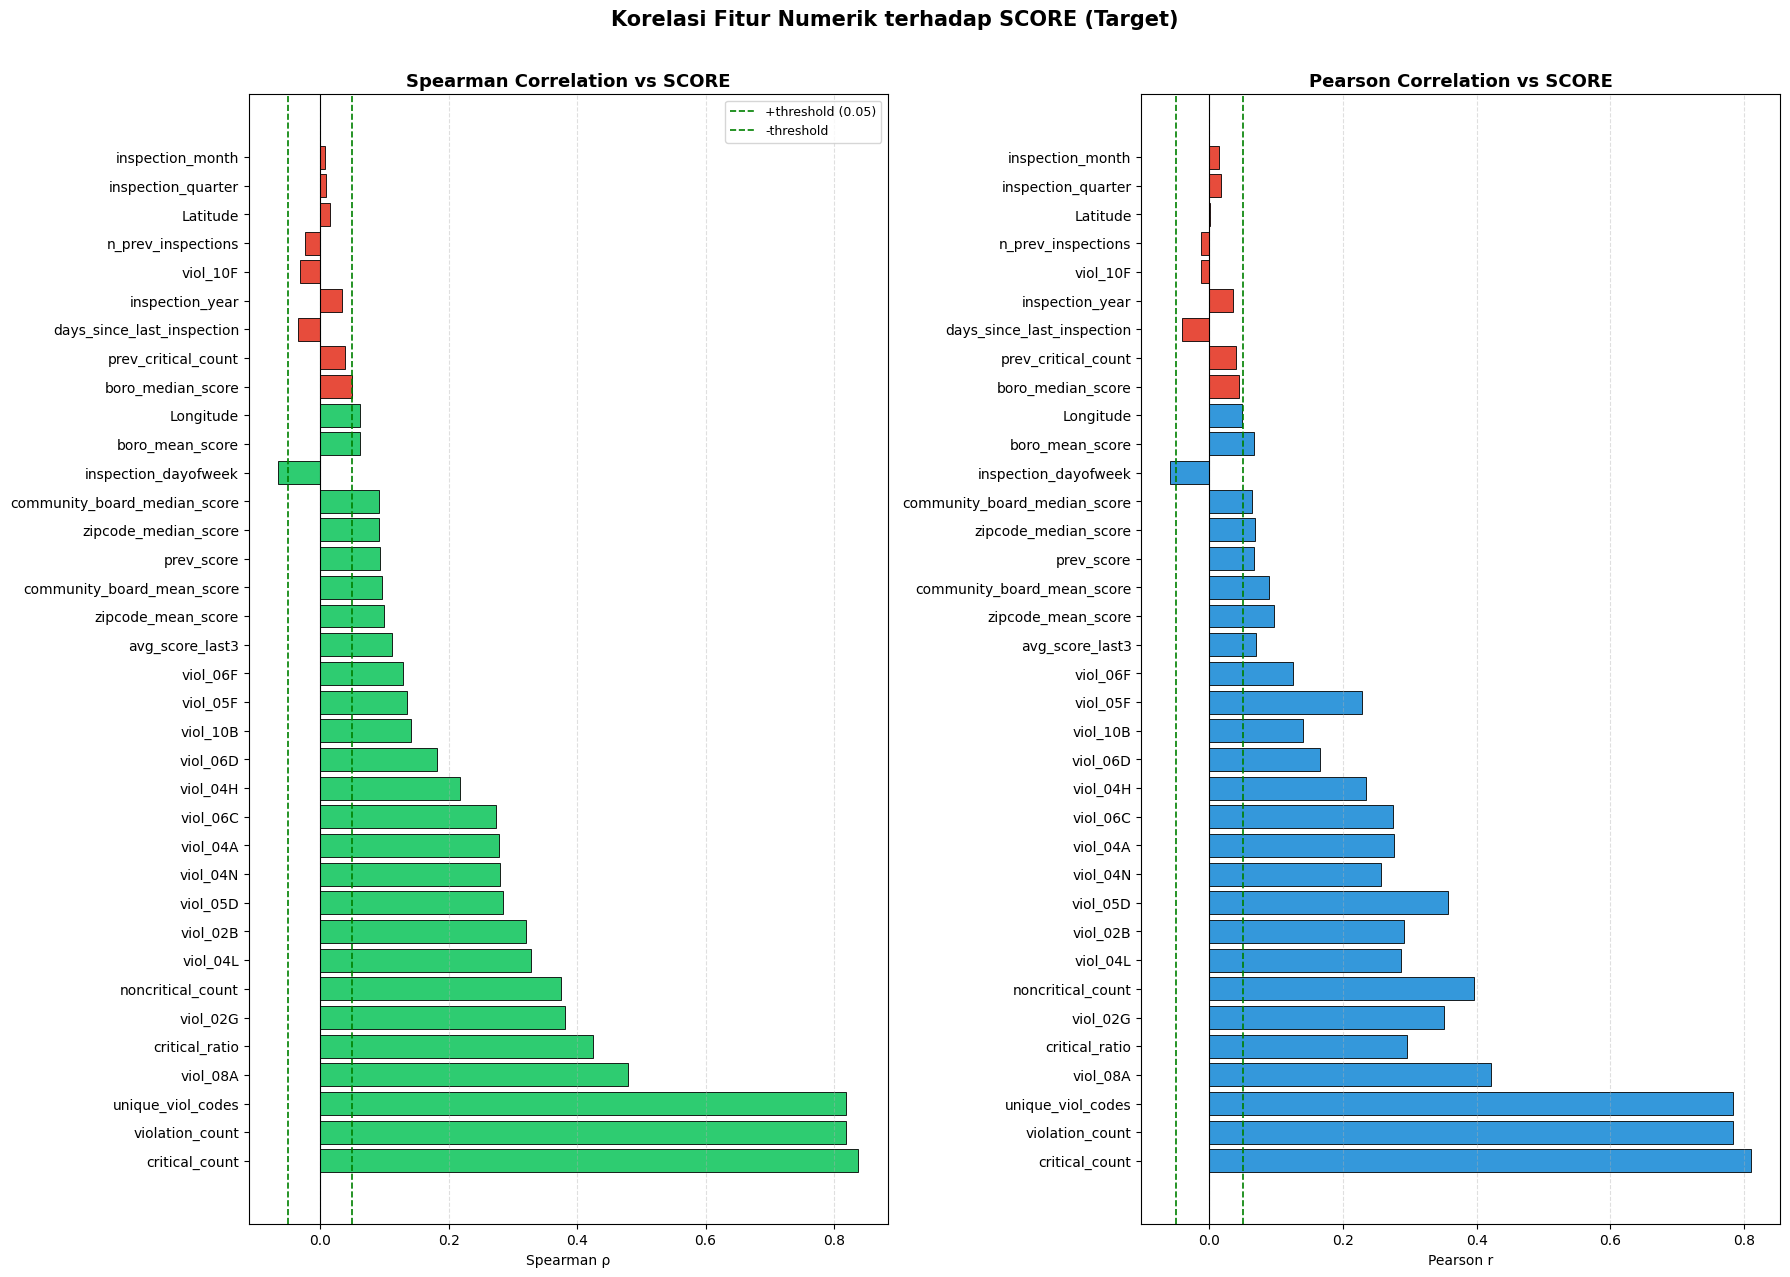


Fitur LEMAH (akan dipertimbangkan untuk di-drop):
['boro_median_score', 'prev_critical_count', 'days_since_last_inspection', 'inspection_year', 'viol_10F', 'n_prev_inspections', 'Latitude', 'inspection_quarter', 'inspection_month']

Fitur KUAT (dipertahankan):
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'viol_06F', 'avg_score_last3', 'zipcode_mean_score', 'community_board_mean_score', 'prev_score', 'zipcode_median_score', 'community_board_median_score', 'inspection_dayofweek', 'boro_mean_score', 'Longitude']


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_corr) * 0.35)))

colors_sp = ["#2ecc71" if k else "#e74c3c" for k in df_corr["keep"]]

axes[0].barh(df_corr["feature"], df_corr["spearman_r"], color=colors_sp, edgecolor="black", linewidth=0.6)

axes[0].axvline(0, color="black", linewidth=0.8)

axes[0].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"+threshold ({SPEARMAN_THRESHOLD})")

axes[0].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"-threshold")

axes[0].set_title("Spearman Correlation vs SCORE", fontsize=13, fontweight="bold")

axes[0].set_xlabel("Spearman ρ")

axes[0].legend(fontsize=9)

axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_pe = ["#3498db" if k else "#e74c3c" for k in df_corr["keep"]]

axes[1].barh(df_corr["feature"], df_corr["pearson_r"], color=colors_pe, edgecolor="black", linewidth=0.6)

axes[1].axvline(0, color="black", linewidth=0.8)

axes[1].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)

axes[1].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)

axes[1].set_title("Pearson Correlation vs SCORE", fontsize=13, fontweight="bold")

axes[1].set_xlabel("Pearson r")

axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Korelasi Fitur Numerik terhadap SCORE (Target)", fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()

plt.show()

print("\nFitur LEMAH (akan dipertimbangkan untuk di-drop):")

print(df_corr[~df_corr["keep"]]["feature"].tolist())

print("\nFitur KUAT (dipertahankan):")

print(df_corr[df_corr["keep"]]["feature"].tolist())

In [36]:
cat_cols_to_check = [

    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"

]

eta_results = []

for col in cat_cols_to_check:

    tmp = df_base[[col, "SCORE"]].dropna().copy()

    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]

    if len(groups) < 2:

        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()

    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)

    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)

    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({

        "feature":    col,

        "f_stat":     round(f_stat, 4),

        "p_value":    round(p_val, 6),

        "eta_squared": round(eta_sq, 6),

        "n_categories": tmp[col].nunique(),

    })

df_eta = (

    pd.DataFrame(eta_results)

    .sort_values("eta_squared", ascending=False)

    .reset_index(drop=True)

)

ETA_THRESHOLD = 0.01

df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD

df_eta["effect_size"] = df_eta["eta_squared"].apply(

    lambda x: "Large (η²≥0.14)" if x >= 0.14

    else "Medium (η²≥0.06)" if x >= 0.06

    else "Small (η²≥0.01)" if x >= 0.01

    else "Negligible"

)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")

print()

df_eta

Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


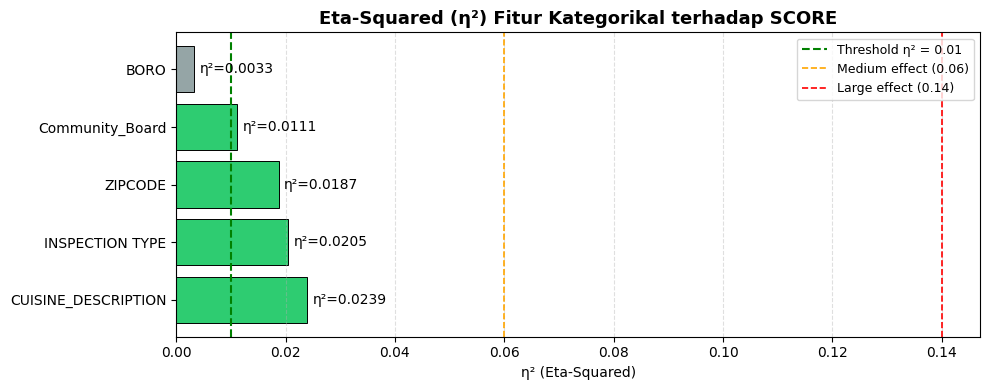

In [37]:
fig, ax = plt.subplots(figsize=(10, max(4, len(df_eta) * 0.7)))

color_map = {

    "Large (η²≥0.14)":   "#c0392b",

    "Medium (η²≥0.06)":  "#e67e22",

    "Small (η²≥0.01)":   "#2ecc71",

    "Negligible":         "#95a5a6",

}

bar_colors = [color_map[e] for e in df_eta["effect_size"]]

bars = ax.barh(df_eta["feature"], df_eta["eta_squared"],

               color=bar_colors, edgecolor="black", linewidth=0.7)

ax.axvline(ETA_THRESHOLD, color="green", linestyle="--", linewidth=1.5,

           label=f"Threshold η² = {ETA_THRESHOLD}")

ax.axvline(0.06, color="orange", linestyle="--", linewidth=1.2, label="Medium effect (0.06)")

ax.axvline(0.14, color="red",    linestyle="--", linewidth=1.2, label="Large effect (0.14)")

for bar, val in zip(bars, df_eta["eta_squared"]):

    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,

            f"η²={val:.4f}", va="center", fontsize=10)

ax.set_title("Eta-Squared (η²) Fitur Kategorikal terhadap SCORE", fontsize=13, fontweight="bold")

ax.set_xlabel("η² (Eta-Squared)")

ax.legend(fontsize=9)

ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [38]:
print("=" * 65)

print("  REKOMENDASI FITUR BERDASARKAN KORELASI")

print("=" * 65)

keep_num  = df_corr[df_corr["keep"]]["feature"].tolist()

drop_num  = df_corr[~df_corr["keep"]]["feature"].tolist()

keep_cat  = df_eta[df_eta["keep"]]["feature"].tolist()

drop_cat  = df_eta[~df_eta["keep"]]["feature"].tolist()

print(f"\nFitur NUMERIK dipertahankan ({len(keep_num)}):")

for f in keep_num:

    row = df_corr[df_corr["feature"] == f].iloc[0]

    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur NUMERIK lemah — pertimbangkan DROP ({len(drop_num)}):")

for f in drop_num:

    row = df_corr[df_corr["feature"] == f].iloc[0]

    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur KATEGORIKAL dipertahankan ({len(keep_cat)}):")

for f in keep_cat:

    row = df_eta[df_eta["feature"] == f].iloc[0]

    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

print(f"\nFitur KATEGORIKAL lemah — pertimbangkan DROP ({len(drop_cat)}):")

for f in drop_cat:

    row = df_eta[df_eta["feature"] == f].iloc[0]

    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

recommended_num = keep_num

recommended_cat = keep_cat

print(f"\n{'='*65}")

print(f"  TOTAL FITUR DIREKOMENDASIKAN: {len(recommended_num) + len(recommended_cat)}")

print(f"  Numerik: {len(recommended_num)}  |  Kategorikal: {len(recommended_cat)}")

print(f"{'='*65}")

  REKOMENDASI FITUR BERDASARKAN KORELASI

Fitur NUMERIK dipertahankan (27):
   critical_count                           ρ=+0.8381  p=0.0000
   violation_count                          ρ=+0.8187  p=0.0000
   unique_viol_codes                        ρ=+0.8187  p=0.0000
   viol_08A                                 ρ=+0.4795  p=0.0000
   critical_ratio                           ρ=+0.4245  p=0.0000
   viol_02G                                 ρ=+0.3808  p=0.0000
   noncritical_count                        ρ=+0.3756  p=0.0000
   viol_04L                                 ρ=+0.3289  p=0.0000
   viol_02B                                 ρ=+0.3208  p=0.0000
   viol_05D                                 ρ=+0.2845  p=0.0000
   viol_04N                                 ρ=+0.2806  p=0.0000
   viol_04A                                 ρ=+0.2784  p=0.0000
   viol_06C                                 ρ=+0.2740  p=0.0000
   viol_04H                                 ρ=+0.2171  p=0.0000
   viol_06D                 

In [39]:
FINAL_NUM_FEATURES = recommended_num + ['days_since_last_inspection']

FINAL_CAT_FEATURES = recommended_cat

print("Daftar fitur numerik final:")

print(FINAL_NUM_FEATURES)

print()

print("Daftar fitur kategorikal final:")

print(FINAL_CAT_FEATURES)

Daftar fitur numerik final:
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'viol_06F', 'avg_score_last3', 'zipcode_mean_score', 'community_board_mean_score', 'prev_score', 'zipcode_median_score', 'community_board_median_score', 'inspection_dayofweek', 'boro_mean_score', 'Longitude', 'days_since_last_inspection']

Daftar fitur kategorikal final:
['CUISINE_DESCRIPTION', 'INSPECTION TYPE', 'ZIPCODE', 'Community_Board']


## Step 5 - Apply Drop Fitur Lemah Berdasarkan Correlation Analysis ##

**Keputusan drop berdasarkan hasil korelasi:**

| Fitur | Alasan Drop |
|---|---|
| `inspection_month`, `inspection_quarter`, `inspection_year` | ρ < 0.04, tidak ada pola temporal signifikan |
| `inspection_dayofweek` | ρ = -0.066, lolos tipis tapi makna meragukan |
| `Latitude` | ρ = 0.016, sangat lemah — Longitude lebih diskriminatif |
| `BORO` | η² = 0.003 (Negligible) — sudah ter-capture di `boro_mean_score` |
| `boro_median_score` | ρ = 0.042, di bawah threshold — pakai `boro_mean_score` saja |
| `prev_critical_count` | ρ = 0.038, redundan dengan `critical_count` saat ini |
| `n_prev_inspections` | ρ = -0.023, tidak prediktif |
| `viol_10F` | ρ = -0.031, frekuensi tinggi di EDA tapi tidak diskriminatif untuk score |
| `ever_had_critical` | Boolean lemah, sudah di-cover oleh `has_critical` & `critical_count` |


In [40]:
cols_to_drop = [

    "inspection_month",

    "inspection_quarter",

    "inspection_year",

    "inspection_dayofweek",

    "Latitude",

    "boro_median_score",

    "BORO",

    "prev_critical_count",

    "n_prev_inspections",

    "days_since_last_inspection",

    "ever_had_critical",

    "viol_10F",

]

cols_to_drop_exist = [c for c in cols_to_drop if c in df_base.columns]

cols_not_found     = [c for c in cols_to_drop if c not in df_base.columns]

df_base = df_base.drop(columns=cols_to_drop_exist)

print(f"Kolom di-drop ({len(cols_to_drop_exist)}): {cols_to_drop_exist}")

if cols_not_found:

    print(f"Tidak ditemukan (skip): {cols_not_found}")

print(f"\nShape df_base setelah drop: {df_base.shape}")

print(f"\nKolom tersisa ({len(df_base.columns)}):")

print(df_base.columns.tolist())

Kolom di-drop (12): ['inspection_month', 'inspection_quarter', 'inspection_year', 'inspection_dayofweek', 'Latitude', 'boro_median_score', 'BORO', 'prev_critical_count', 'n_prev_inspections', 'days_since_last_inspection', 'ever_had_critical', 'viol_10F']

Shape df_base setelah drop: (68860, 34)

Kolom tersisa (34):
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'ZIPCODE', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score']


## Step 6 - Advanced Preprocessing: Encoding Variabel Kategorikal ##

**Strategi encoding berdasarkan hasil korelasi:**

| Fitur | Strategi | Alasan |
|---|---|---|
| `INSPECTION TYPE` | **One-Hot Encoding** | 6 kategori (top 5 + Other), η²=0.021 |
| `ZIPCODE` | **Drop raw** → sudah ada `zipcode_mean_score` & `zipcode_median_score` | Ratusan kategori, encoding numeriknya lebih informatif |
| `Community_Board` | **Drop raw** → sudah ada `community_board_median_score` | Sama seperti ZIPCODE |

**Catatan:** `CAMIS` dan `INSPECTION DATE` adalah identifier — tidak ikut di-encode, di-drop sebelum modeling.


In [41]:
ohe_cols = ["INSPECTION TYPE"]

df_encoded = pd.get_dummies(

    df_base,

    columns=ohe_cols,

    prefix={"INSPECTION TYPE": "instype"},

    drop_first=False,

    dtype=int

)

print(f"Shape sebelum OHE: {df_base.shape}")

print(f"Shape setelah OHE: {df_encoded.shape}")

print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")

new_ohe_cols = [c for c in df_encoded.columns if c.startswith("cuisine_") or c.startswith("instype_")]

print(new_ohe_cols)

Shape sebelum OHE: (68860, 34)
Shape setelah OHE: (68860, 39)
Kolom baru dari OHE (5):
['instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [42]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board", "CUISINE_DESCRIPTION"]

id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(

    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]

)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")

print()

print("Kolom final df_encoded:")

print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 34)

Kolom final df_encoded:
['SCORE', 'Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [43]:
df_encoded["has_critical"] = df_encoded["has_critical"].astype(int)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:

    print(f"Masih ada kolom non-numerik: {non_numeric}")

    print("Perlu ditangani sebelum modeling!")

else:

    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")

print(f"Missing values total: {df_encoded.isna().sum().sum()}")

print()

print("=== Dtypes summary ===")

print(df_encoded.dtypes.value_counts())

print()

print("=== Preview 5 baris pertama ===")

df_encoded.head()

Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling

Shape final: (68860, 34)
Missing values total: 0

=== Dtypes summary ===
float64    27
int64       7
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Longitude,critical_count,has_critical,noncritical_count,violation_count,unique_viol_codes,critical_ratio,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,prev_score,avg_score_last3,boro_mean_score,zipcode_mean_score,zipcode_median_score,community_board_mean_score,community_board_median_score,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
28286,13.0,-73.844604,1.0,1,1.0,2.0,2.0,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,17.384430,18.018182,13.0,17.594313,13.0,1,0,0,0,0,0
44139,12.0,-73.951096,1.0,1,2.0,3.0,3.0,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,13.0,17.723636,19.514851,12.0,9.600000,12.0,0,1,0,0,0,0
4697,2.0,-73.978370,0.0,0,1.0,1.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,18.158726,16.345588,12.0,17.113572,12.0,1,0,0,0,0,0
28080,2.0,-73.988206,0.0,0,1.0,1.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,2.000000,18.298113,13.0,2.000000,2.0,1,0,0,0,0,0
40124,4.0,-73.846616,0.0,0,2.0,2.0,2.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,13.0,13.000000,13.000000,13.0,13.000000,13.0,0,0,0,0,1,0


In [44]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [

    "violation_count", "critical_count", "noncritical_count",

    "unique_viol_codes", "critical_ratio"

]

for col in cols_to_winsorize:

    upper = df_encoded[col].quantile(0.99)

    df_encoded[col] = df_encoded[col].clip(upper=upper)

    print(f"{col:<25} capped at P99 = {upper:.2f}")

print("\nWinsorize fitur numerik selesai")

violation_count           capped at P99 = 10.00
critical_count            capped at P99 = 7.00
noncritical_count         capped at P99 = 4.00
unique_viol_codes         capped at P99 = 10.00
critical_ratio            capped at P99 = 1.00

Winsorize fitur numerik selesai


In [45]:
skew_df = (

    df_encoded[[c for c in df_encoded.columns

                if not any(c.startswith(p) for p in

                          ["cuisine_", "instype_", "viol_"])

                and c not in ["has_critical", "SCORE"]]]

    .skew()

    .abs()

    .sort_values(ascending=False)

    .reset_index()

    .rename(columns={"index": "feature", 0: "abs_skewness"})

)

skew_df["perlu_log"] = skew_df["abs_skewness"] > 1.0

print(skew_df.to_string(index=False))

                     feature  abs_skewness  perlu_log
        zipcode_median_score      6.455681       True
community_board_median_score      6.093655       True
          zipcode_mean_score      1.381656       True
              critical_count      1.120576       True
             boro_mean_score      1.051210       True
             violation_count      1.007890       True
           unique_viol_codes      1.007890       True
           noncritical_count      0.536622      False
  community_board_mean_score      0.434554      False
             avg_score_last3      0.401437      False
                  prev_score      0.384908      False
                   Longitude      0.206318      False
              critical_ratio      0.129107      False


In [46]:
for col in ["critical_count", "violation_count", "unique_viol_codes"]:

    df_encoded[col] = np.log1p(df_encoded[col])

    print(f"{col} → log1p applied")

critical_count → log1p applied
violation_count → log1p applied
unique_viol_codes → log1p applied


Total fitur masuk modeling: 33
Fitur dengan |ρ| ≥ 0.05: 30
Fitur dengan |ρ| < 0.05: 3



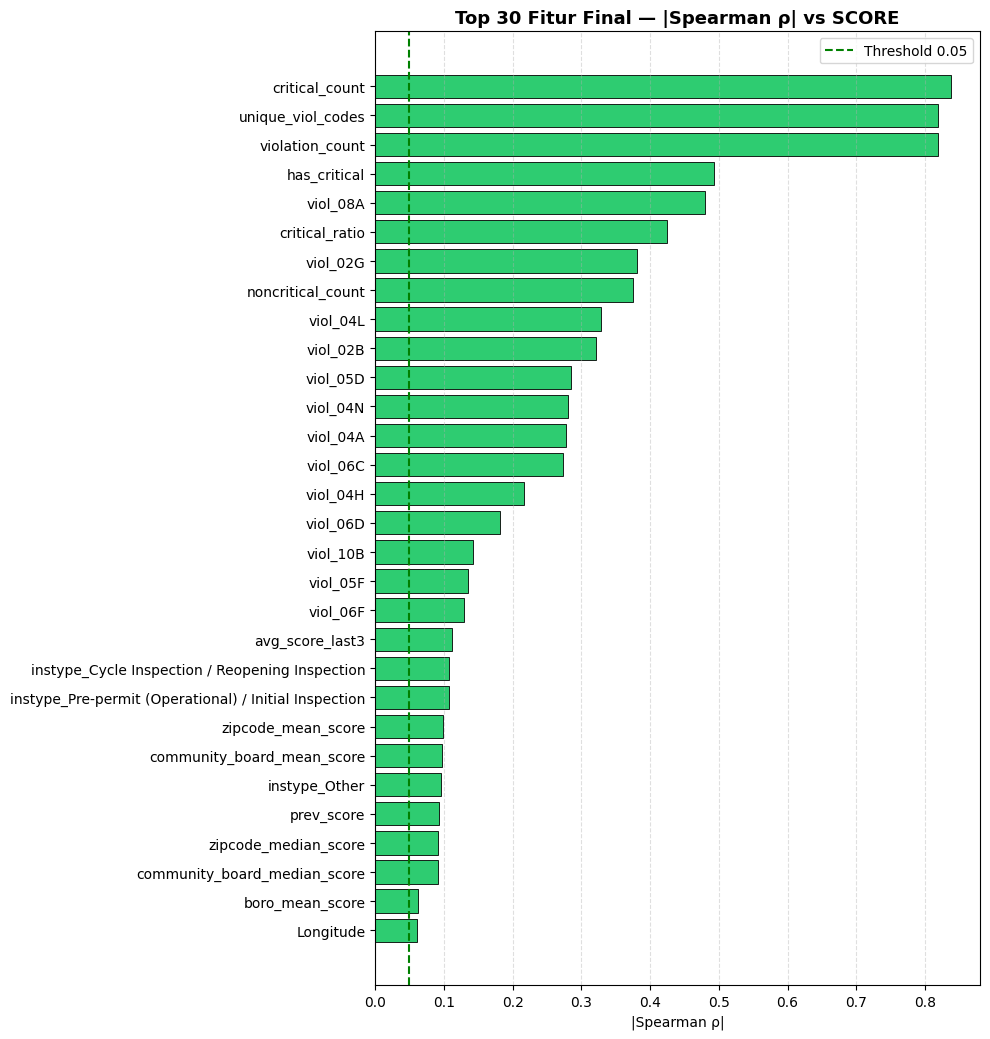


=== Top 10 fitur paling prediktif ===
          feature  abs_spearman_rho
   critical_count          0.838132
unique_viol_codes          0.818710
  violation_count          0.818710
     has_critical          0.492786
         viol_08A          0.479486
   critical_ratio          0.424466
         viol_02G          0.380793
noncritical_count          0.375468
         viol_04L          0.328939
         viol_02B          0.320815


In [47]:
final_corr = (

    df_encoded.corr(method="spearman")["SCORE"]

    .drop("SCORE")

    .abs()

    .sort_values(ascending=False)

    .reset_index()

    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})

)

print(f"Total fitur masuk modeling: {len(final_corr)}")

print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")

print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")

print()

top_n = min(30, len(final_corr))

plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))

colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]

ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],

        color=colors, edgecolor="black", linewidth=0.6)

ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")

ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")

ax.set_xlabel("|Spearman ρ|")

ax.legend()

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

print("\n=== Top 10 fitur paling prediktif ===")

print(final_corr.head(10).to_string(index=False))

## Step 7 - Advanced Preprocessing: Handling Outlier pada SCORE ##

**Konteks dari EDA:**
- Distribusi SCORE **right-skewed** — mayoritas score berkumpul di 0–25, ada ekor panjang ke kanan
- Outlier score tinggi tetap **informatif** — bukan noise, melainkan inspeksi berisiko tinggi

**Strategi: Winsorize dulu → lalu Log1p Transform**

| Teknik | Fungsi | Urutan |
|---|---|---|
| **Winsorize (P99)** | Potong nilai ekstrem agar tidak mendominasi log scale | 1️⃣ |
| **Log1p Transform** | Perbaiki right-skewness distribusi → mendekati normal | 2️⃣ |

Mengapa log1p dan bukan log biasa? Karena SCORE bisa bernilai **0** → `log(0) = -inf`.
`log1p(x) = log(x + 1)` aman untuk nilai 0.

⚠️ **Konsekuensi:** Prediksi model akan dalam skala log → saat evaluasi dan interpretasi,
hasil prediksi harus dikembalikan ke skala asli dengan `np.expm1(y_pred)`.


=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


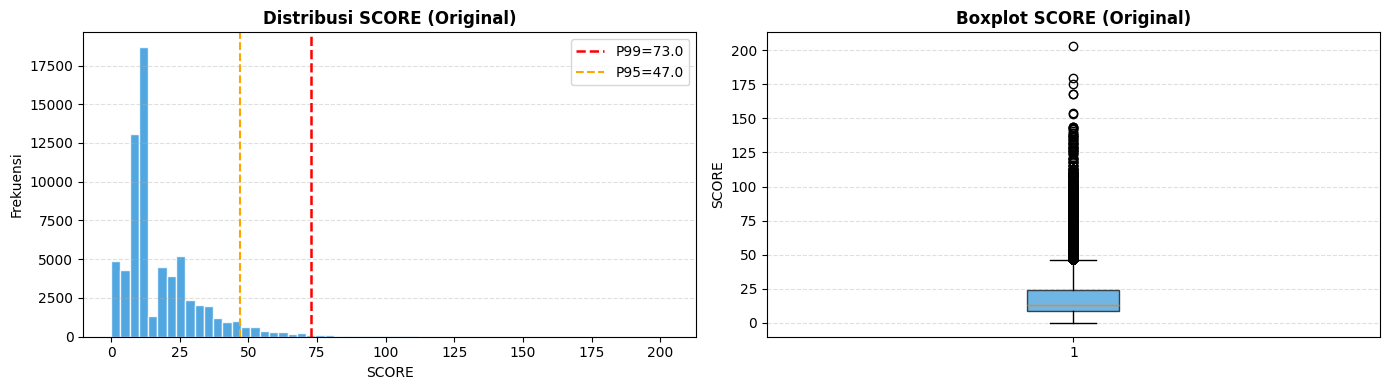

In [48]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)

q3  = score.quantile(0.75)

iqr = q3 - q1

p99 = score.quantile(0.99)

p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")

print(f"Min    : {score.min():.1f}")

print(f"Q1     : {q1:.1f}")

print(f"Median : {score.median():.1f}")

print(f"Mean   : {score.mean():.2f}")

print(f"Q3     : {q3:.1f}")

print(f"P95    : {p95:.1f}")

print(f"P99    : {p99:.1f}")

print(f"Max    : {score.max():.1f}")

print(f"Skewness: {score.skew():.3f}")

print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")

print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)

axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")

axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")

axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")

axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")

axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))

axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")

axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [49]:
score_before_transform = df_encoded["SCORE"].copy()

In [50]:
CAP_PERCENTILE = 0.99

score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)

df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")

print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")

print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")

print()

df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")

print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")

print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")

print()

[Winsorize] Cap di P99 = 73.0
Baris yang di-cap: 700
Skewness setelah winsorize: 1.621

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -0.714
Range SCORE sekarang        : [0.000, 4.304]



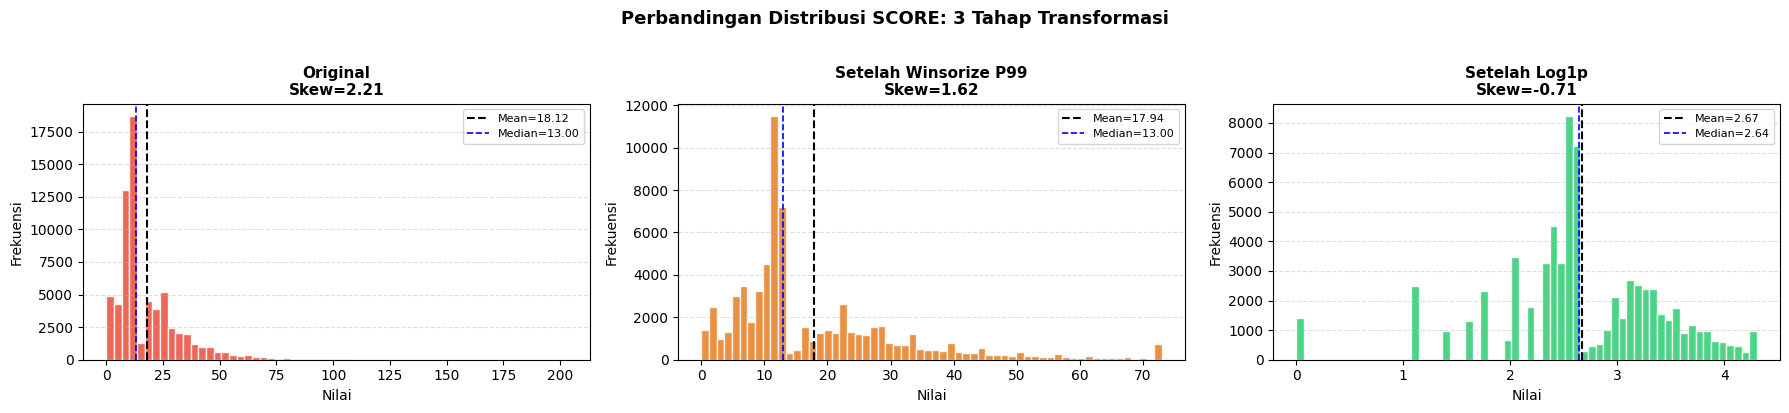

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

score_original  = score_before_transform

score_winsorize = score_before_transform.clip(upper=score_cap)

score_log1p     = df_encoded["SCORE"]

data_stages = [

    (score_original,  f"Original",  "#e74c3c"),

    (score_winsorize, f"Setelah Winsorize P99", "#e67e22"),

    (score_log1p,     f"Setelah Log1p", "#2ecc71"),

]

for ax, (data, title, color) in zip(axes, data_stages):

    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)

    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,

               label=f"Mean={data.mean():.2f}")

    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,

               label=f"Median={data.median():.2f}")

    ax.set_title(title, fontsize=11, fontweight="bold")

    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")

    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",

             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()

plt.show()

## Step 8 - Advanced Preprocessing: Train-Test Split (Temporal) ##

**Mengapa 3-Way Temporal Split (Train / Validation / Test)?**

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Tuning hyperparameter, pilih model terbaik |
| **Test** | 15% | Evaluasi final — **hanya disentuh sekali di akhir** |

Kalau hanya pakai train/test dan tuning dilakukan berdasarkan test set → test set "bocor" ke proses
training secara tidak langsung → hasil evaluasi **overly optimistic**, tidak mencerminkan performa di data baru.

Split tetap **temporal** dan berurutan karena data ini time-series inspeksi:
```
[────── Train (70%) ──────────][── Val (15%) ──][── Test (15%) ──]
 terlama                                                  terbaru
```

⚠️  **Target encoding di-refit dari train saja**, lalu di-apply ke val dan test.


In [52]:
df_split = df_encoded.copy()

df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)

df_split["CAMIS"]           = df_ids["CAMIS"].values

df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)

train_end = int(n * 0.70)

val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()

val_df   = df_split.iloc[train_end:val_end].copy()

test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")

print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")

print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")

print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")

print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")

print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")

print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


In [53]:
te_map = {

    "zipcode_mean_score":            ("ZIPCODE",         "mean"),

    "zipcode_median_score":          ("ZIPCODE",         "median"),

    "boro_mean_score":               ("BORO",            "mean"),

    "community_board_median_score":  ("Community_Board", "median"),

    "community_board_mean_score":    ("Community_Board", "mean"),

}

camis_geo = (

    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]

    .copy()

    .astype(str)

    .replace("nan", pd.NA)

    .dropna(subset=["CAMIS"])

    .groupby("CAMIS", as_index=False)

    .first()

)

for df_ in [train_df, val_df, test_df]:

    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:

    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]

    for df_ in [train_df, val_df, test_df]:

        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():

    if new_col not in train_df.columns:

        continue

    stats_dict = (

        train_df.dropna(subset=[geo_col])

        .groupby(geo_col)["SCORE"]

        .agg(agg_fn)

        .to_dict()

    )

    for df_ in [train_df, val_df, test_df]:

        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]

for df_ in [train_df, val_df, test_df]:

    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")

print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 36) | Val: (10329, 36) | Test: (10329, 36)


In [54]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")

y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")

y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")

y_test  = test_df["SCORE"]

print("=" * 55)

print("  HASIL AKHIR PREPROCESSING")

print("=" * 55)

print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")

print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")

print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")

print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")

print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")

print(f"\nFeature list:")

print(X_train.columns.tolist())

  HASIL AKHIR PREPROCESSING
X_train : (48202, 33)  | y mean=2.667, std=0.769
X_val   : (10329, 33)   | y mean=2.673, std=0.878
X_test  : (10329, 33)   | y mean=2.704, std=0.760

Jumlah fitur masuk modeling: 33

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Feature list:
['Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-i

**Target Encoding untuk Cuisine Description pada masing-masing train, val, dan test**

In [55]:
camis_cuisine = (

    df_ins[["CAMIS", "CUISINE_DESCRIPTION"]]

    .astype(str)

    .groupby("CAMIS")

    .agg(lambda x: x.mode().iloc[0])

    .reset_index()

)

for df_ in [train_df, val_df, test_df]:

    df_["CAMIS"] = df_["CAMIS"].astype(str)

camis_to_cuisine = camis_cuisine.set_index("CAMIS")["CUISINE_DESCRIPTION"]

train_df["CUISINE_DESCRIPTION"] = train_df["CAMIS"].map(camis_to_cuisine)

val_df["CUISINE_DESCRIPTION"]   = val_df["CAMIS"].map(camis_to_cuisine)

test_df["CUISINE_DESCRIPTION"]  = test_df["CAMIS"].map(camis_to_cuisine)

global_median = train_df["SCORE"].median()

cuisine_mean  = train_df.groupby("CUISINE_DESCRIPTION")["SCORE"].mean().to_dict()

for df_, X_ in [(train_df, X_train), (val_df, X_val), (test_df, X_test)]:

    X_["cuisine_encoded"] = df_["CUISINE_DESCRIPTION"].map(cuisine_mean).fillna(global_median)

for df_ in [train_df, val_df, test_df]:

    df_.drop(columns=["CUISINE_DESCRIPTION"], errors="ignore", inplace=True)

print("✅ Target encoding CUISINE_DESCRIPTION selesai")

print(f"Jumlah kategori cuisine : {len(cuisine_mean)}")

print(f"Sample nilai encoding   : {dict(list(cuisine_mean.items())[:5])}")

✅ Target encoding CUISINE_DESCRIPTION selesai
Jumlah kategori cuisine : 90
Sample nilai encoding   : {'Afghan': 2.833123504308041, 'African': 2.98006820811021, 'American': 2.588143369693703, 'Armenian': 2.802479903522276, 'Asian/Asian Fusion': 2.848377820941733}


## Step 9 - Advanced Preprocessing: Feature Scaling ##

**Strategi Scaling:**

| Kolom | Scaler | Alasan |
|---|---|---|
| `SCORE` (target) | **Tidak di-scale** | Target regresi dibiarkan asli agar prediksi tetap interpretable |
| Fitur numerik kontinyu (score historis, koordinat, dll) | **RobustScaler** | Tahan terhadap outlier — menggunakan median & IQR bukan mean & std |
| Fitur count (violation_count, critical_count, dll) | **RobustScaler** | Distribusinya skewed, RobustScaler lebih aman |
| Fitur binary OHE (`cuisine_*`, `instype_*`, `viol_*`, `has_critical`) | **Tidak di-scale** | Sudah 0/1, scaling justru merusak interpretasi |

**Mengapa RobustScaler bukan StandardScaler?**
SCORE dan violation features punya outlier signifikan. StandardScaler akan terpengaruh mean & std yang terdistorsi outlier, sehingga fitur normal jadi ter-compress. RobustScaler memakai median & IQR sehingga lebih stabil.


In [56]:
from sklearn.preprocessing import RobustScaler

binary_cols = (

    [c for c in X_train.columns if c.startswith("cuisine_")]

    + [c for c in X_train.columns if c.startswith("instype_")]

    + [c for c in X_train.columns if c.startswith("viol_")]

    + ["has_critical"]

)

binary_cols = [c for c in binary_cols if c in X_train.columns]

scale_cols = [

    c for c in X_train.select_dtypes(include="number").columns

    if c not in binary_cols

]

scaler = RobustScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_val[scale_cols]   = scaler.transform(X_val[scale_cols])

X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"✅ RobustScaler di-fit dari train, applied ke val & test")

print(f"Kolom di-scale ({len(scale_cols)}): {scale_cols}")

✅ RobustScaler di-fit dari train, applied ke val & test
Kolom di-scale (13): ['Longitude', 'critical_count', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score']


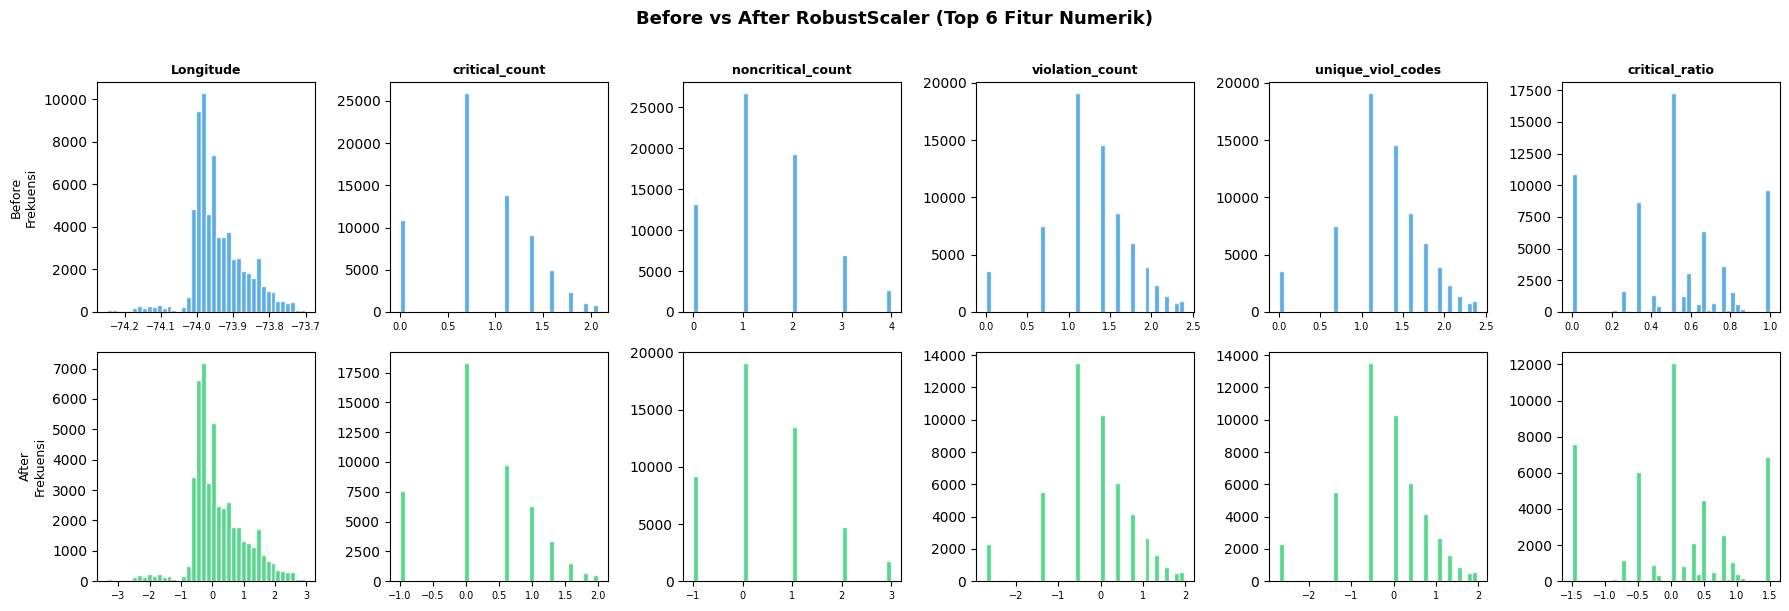

In [57]:
top6_scale = [c for c in X_train.columns if c in scale_cols][:6]

df_before = df_encoded[top6_scale].copy()

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):

    axes[0, i].hist(df_before[col].dropna(), bins=40,

                    color="#3498db", edgecolor="white", alpha=0.8)

    axes[0, i].set_title(col, fontsize=9, fontweight="bold")

    axes[0, i].tick_params(axis="x", labelsize=7)

    if i == 0: axes[0, i].set_ylabel("Before\nFrekuensi", fontsize=9)

    axes[1, i].hist(X_train[col].dropna(), bins=40,

                    color="#2ecc71", edgecolor="white", alpha=0.8)

    axes[1, i].tick_params(axis="x", labelsize=7)

    if i == 0: axes[1, i].set_ylabel("After\nFrekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)",

             fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()

plt.show()

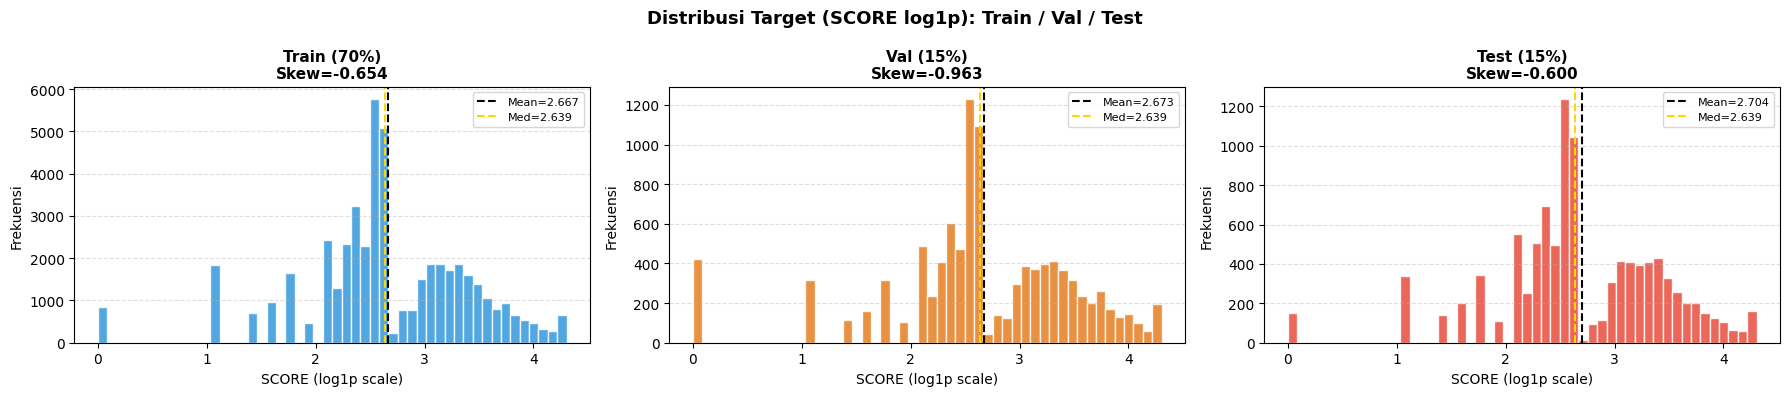

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.600


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [

    (y_train, "Train (70%)",  "#3498db"),

    (y_val,   "Val (15%)",    "#e67e22"),

    (y_test,  "Test (15%)",   "#e74c3c"),

]

for ax, (data, label, color) in zip(axes, sets):

    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)

    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,

               label=f"Mean={data.mean():.3f}")

    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,

               label=f"Med={data.median():.3f}")

    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")

    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")

    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",

             fontsize=13, fontweight="bold")

plt.tight_layout()

plt.show()

print("Cek: distribusi ketiga set harus mirip")

print(f"Train skewness : {y_train.skew():.3f}")

print(f"Val   skewness : {y_val.skew():.3f}")

print(f"Test  skewness : {y_test.skew():.3f}")

## Step 10 - Advanced Preprocessing: Geospatial Density Features ##

**Hasil eksperimen menunjukkan:** Geospatial Density radius **1km** memberikan peningkatan konsisten
pada semua 4 model (Avg Val R² +0.0006) dengan tidak ada model yang memburuk.

**Fitur yang ditambahkan:**
- `density_high_1000m` — jumlah inspeksi restoran dengan SCORE > P75 dalam radius 1km dari lokasi inspeksi ini
- `density_mean_1000m` — rata-rata SCORE restoran tetangga dalam radius 1km

**Anti-leakage:** BallTree dibangun dari **koordinat train set saja**. Val dan test set hanya di-query, tidak ikut membangun tree.

**Catatan:** Restoran tanpa koordinat valid (Latitude/Longitude) di-fill dengan nilai median — baris ini tidak hilang dari dataset.


In [59]:
from sklearn.neighbors import BallTree

print("Menghitung Geospatial Density Features (radius 1km)...")

df_geo = df_ins[["CAMIS", "Latitude", "Longitude", "SCORE"]].copy()

df_geo["Latitude"]  = pd.to_numeric(df_geo["Latitude"],  errors="coerce")

df_geo["Longitude"] = pd.to_numeric(df_geo["Longitude"], errors="coerce")

df_geo["SCORE"]     = pd.to_numeric(df_geo["SCORE"],     errors="coerce")

df_geo = df_geo.dropna(subset=["Latitude", "Longitude", "SCORE"])

df_geo["CAMIS"] = df_geo["CAMIS"].astype(str)

n_base = len(df_base)

train_end = int(n_base * 0.70)

val_end   = int(n_base * 0.85)

df_dates = df_base[["CAMIS", "INSPECTION DATE"]].copy()

df_dates["INSPECTION DATE"] = pd.to_datetime(df_dates["INSPECTION DATE"])

df_dates = df_dates.sort_values("INSPECTION DATE").reset_index(drop=True)

df_dates["CAMIS"] = df_dates["CAMIS"].astype(str)

camis_train = set(df_dates.iloc[:train_end]["CAMIS"])

camis_val   = set(df_dates.iloc[train_end:val_end]["CAMIS"])

camis_test  = set(df_dates.iloc[val_end:]["CAMIS"])

tr_geo = df_geo[df_geo["CAMIS"].isin(camis_train)].copy()

vl_geo = df_geo[df_geo["CAMIS"].isin(camis_val)].copy()

te_geo = df_geo[df_geo["CAMIS"].isin(camis_test)].copy()

print(f"  Koordinat valid — Train: {len(tr_geo):,} | Val: {len(vl_geo):,} | Test: {len(te_geo):,}")

score_threshold = tr_geo["SCORE"].quantile(0.75)

train_scores    = tr_geo["SCORE"].values

train_coords_rad = np.radians(tr_geo[["Latitude", "Longitude"]].values)

tree = BallTree(train_coords_rad, metric="haversine")

print(f"  Score P75 threshold: {score_threshold:.2f}")

print(f"  BallTree dibangun dari {len(tr_geo):,} titik train")

def query_density(coords_rad, tree, train_scores, threshold, radius_km=1.0):

    r_rad = radius_km / 6371.0

    indices = tree.query_radius(coords_rad, r=r_rad)

    density_high = [(train_scores[idx] > threshold).sum() for idx in indices]

    density_mean = [train_scores[idx].mean() if len(idx) > 0 else np.nan for idx in indices]

    return density_high, density_mean

for geo_df, X_set, set_name in [

    (tr_geo, X_train, "Train"),

    (vl_geo, X_val,   "Val"),

    (te_geo, X_test,  "Test"),

]:

    coords_rad = np.radians(geo_df[["Latitude", "Longitude"]].values)

    d_high, d_mean = query_density(coords_rad, tree, train_scores, score_threshold)

    density_high_s = pd.Series(d_high, index=geo_df.index)

    density_mean_s = pd.Series(d_mean, index=geo_df.index)

    X_set["density_high_1000m"] = density_high_s.reindex(X_set.index)

    X_set["density_mean_1000m"] = density_mean_s.reindex(X_set.index)

fill_high = X_train["density_high_1000m"].median()

fill_mean = X_train["density_mean_1000m"].median()

for X_ in [X_train, X_val, X_test]:

    X_["density_high_1000m"] = X_["density_high_1000m"].fillna(fill_high)

    X_["density_mean_1000m"] = X_["density_mean_1000m"].fillna(fill_mean)

print(f"\n✅ Geospatial density features ditambahkan")

print(f"  density_high_1000m — median={fill_high:.1f}, "

      f"max={X_train['density_high_1000m'].max():.0f}")

print(f"  density_mean_1000m — median={fill_mean:.2f}, "

      f"max={X_train['density_mean_1000m'].max():.2f}")

print(f"\nShape X_train setelah tambah geo density: {X_train.shape}")

Menghitung Geospatial Density Features (radius 1km)...
  Koordinat valid — Train: 64,902 | Val: 25,761 | Test: 25,974
  Score P75 threshold: 24.00
  BallTree dibangun dari 64,902 titik train

✅ Geospatial density features ditambahkan
  density_high_1000m — median=142.0, max=957
  density_mean_1000m — median=17.44, max=28.14

Shape X_train setelah tambah geo density: (48202, 36)


In [60]:
from scipy import stats

for feat in ["density_high_1000m", "density_mean_1000m"]:

    valid = pd.DataFrame({

        "feat":  X_train[feat],

        "score": y_train

    }).dropna()

    rho, p = stats.spearmanr(valid["feat"], valid["score"])

    print(f"  {feat:<25} ρ={rho:+.4f}  p={p:.4f}")

print()

print(f"Jumlah fitur total setelah Step 10: {X_train.shape[1]}")

  density_high_1000m        ρ=-0.0007  p=0.8830
  density_mean_1000m        ρ=+0.0032  p=0.4820

Jumlah fitur total setelah Step 10: 36


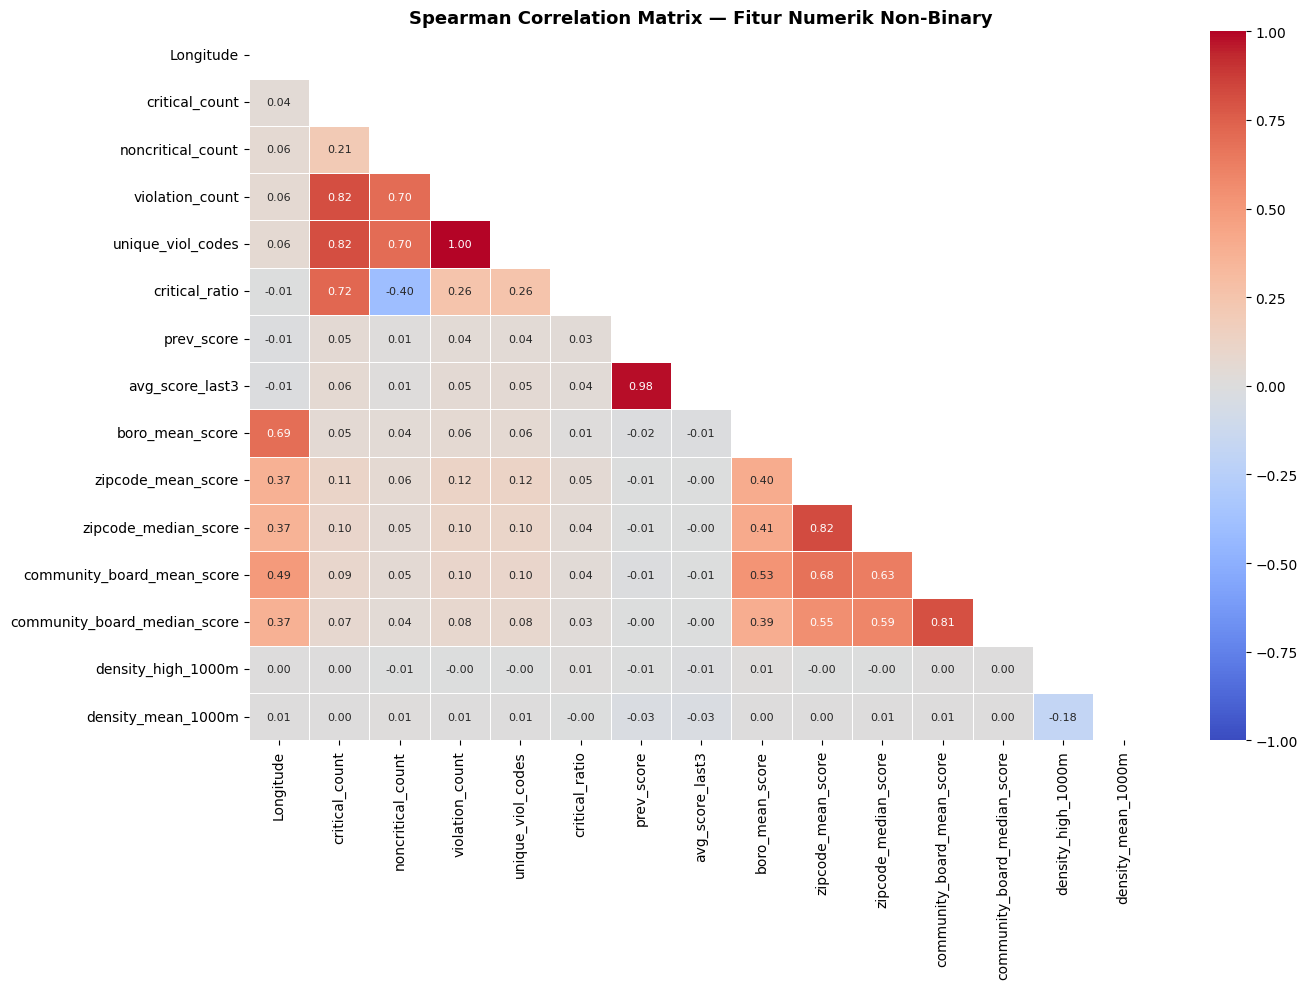

  VIF — Variance Inflation Factor
                     feature        VIF           status
             violation_count        inf   🔴 Tinggi (>10)
           unique_viol_codes        inf   🔴 Tinggi (>10)
             avg_score_last3 234.289531   🔴 Tinggi (>10)
                  prev_score 234.238231   🔴 Tinggi (>10)
              critical_count  12.191489   🔴 Tinggi (>10)
           noncritical_count   8.398632 🟠 Moderat (5-10)
          zipcode_mean_score   6.035654 🟠 Moderat (5-10)
              critical_ratio   5.325820 🟠 Moderat (5-10)
        zipcode_median_score   5.312830 🟠 Moderat (5-10)
  community_board_mean_score   4.764352      ✅ Aman (<5)
community_board_median_score   3.660124      ✅ Aman (<5)
             boro_mean_score   2.229336      ✅ Aman (<5)
                   Longitude   1.856885      ✅ Aman (<5)
          density_mean_1000m   1.019373      ✅ Aman (<5)
          density_high_1000m   1.018845      ✅ Aman (<5)

🔴 Fitur VIF > 10 : 5
🟠 Fitur VIF 5-10 : 4
✅ Fitur VIF

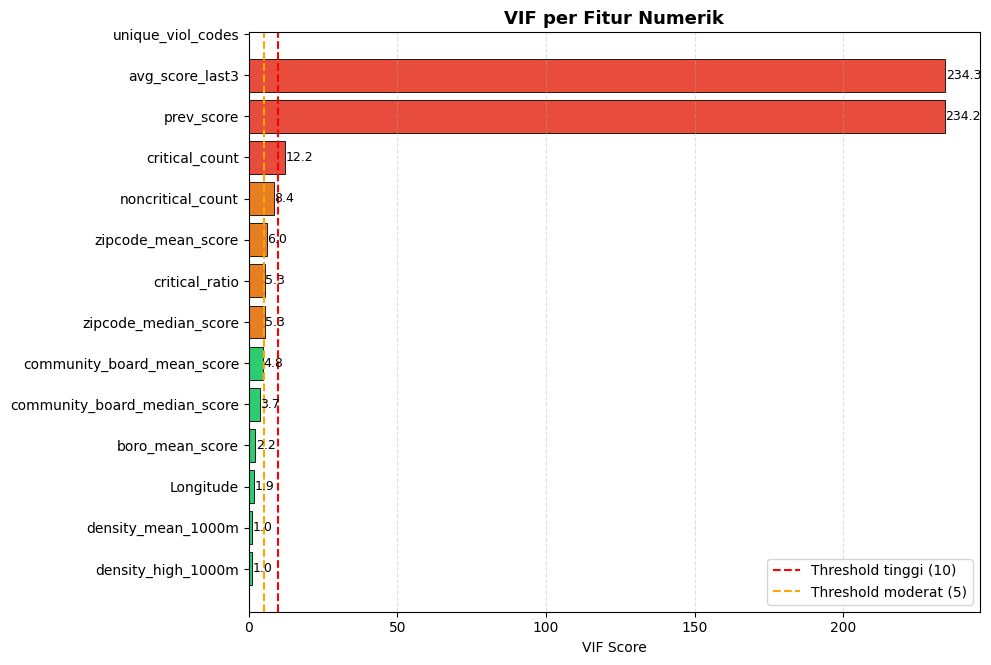

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.tools.tools import add_constant

num_only = [c for c in X_train.columns

            if not any(c.startswith(p) for p in ["cuisine_", "instype_", "viol_"])

            and c != "has_critical"]

corr_matrix = X_train[num_only].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(

    corr_matrix, mask=mask, annot=True, fmt=".2f",

    cmap="coolwarm", center=0, vmin=-1, vmax=1,

    linewidths=0.5, ax=ax, annot_kws={"size": 8}

)

ax.set_title("Spearman Correlation Matrix — Fitur Numerik Non-Binary",

             fontsize=13, fontweight="bold")

plt.tight_layout()

plt.show()

X_vif = X_train[num_only].copy().dropna()

X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({

    "feature": X_vif.columns,

    "VIF": [variance_inflation_factor(X_vif_const.values, i + 1)

            for i in range(len(X_vif.columns))]

}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["status"] = vif_data["VIF"].apply(

    lambda v: "🔴 Tinggi (>10)"   if v > 10

    else      "🟠 Moderat (5-10)" if v > 5

    else      "✅ Aman (<5)"

)

print("=" * 50)

print("  VIF — Variance Inflation Factor")

print("=" * 50)

print(vif_data.to_string(index=False))

print(f"\n🔴 Fitur VIF > 10 : {(vif_data['VIF'] > 10).sum()}")

print(f"🟠 Fitur VIF 5-10 : {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()}")

print(f"✅ Fitur VIF < 5  : {(vif_data['VIF'] <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.45)))

colors = ["#e74c3c" if v > 10 else "#e67e22" if v > 5 else "#2ecc71"

          for v in vif_data["VIF"]]

bars = ax.barh(vif_data["feature"], vif_data["VIF"],

               color=colors, edgecolor="black", linewidth=0.6)

ax.axvline(10, color="red",    linestyle="--", linewidth=1.5, label="Threshold tinggi (10)")

ax.axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="Threshold moderat (5)")

for bar, val in zip(bars, vif_data["VIF"]):

    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,

            f"{val:.1f}", va="center", fontsize=9)

ax.set_title("VIF per Fitur Numerik", fontsize=13, fontweight="bold")

ax.set_xlabel("VIF Score")

ax.legend(); ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

# Modeling ##

**Roadmap Modeling:**

| Tahap | Model | Tujuan |
|---|---|---|
| **1** | Ridge, Lasso, ElasticNet | Atasi overfitting Linear Regression, feature selection implisit |
| **2** | Random Forest, XGBoost, LightGBM | Model non-linear yang lebih powerful untuk data tabular |
| **3** | Perbandingan semua model | Pilih model terbaik berdasarkan Val R² dan gap overfitting |

**Metrik Evaluasi:**
- **RMSE** (log1p scale) — sensitif terhadap error besar
- **MAE** (log1p scale) — lebih robust terhadap outlier
- **R²** — proporsi variansi yang dijelaskan model
- **Gap Train-Val R²** — indikator overfitting (target ≤ 0.05)

⚠️ Semua tuning dilakukan terhadap **Val set**. **Test set hanya digunakan di akhir.**


In [62]:
import re

def clean_col_name(col):

    return re.sub(r'[^A-Za-z0-9_]', '_', col)

X_train.columns = [clean_col_name(c) for c in X_train.columns]

X_val.columns   = [clean_col_name(c) for c in X_val.columns]

X_test.columns  = [clean_col_name(c) for c in X_test.columns]

print("✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama")

print(X_train.columns.tolist())

✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama
['Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle_Inspection___Initial_Inspection', 'instype_Cycle_Inspection___Re_inspection', 'instype_Cycle_Inspection___Reopening_Inspection', 'instype_Other', 'instype_Pre_permit__Operational____Initial_Inspection', 'instype_Pre_permit__Operational____Re_inspection', 'cuisine_encoded', 'density_high_1000m', 'density_mean_1000m']


# Eksperimen: Mengurangi Error di SCORE > 30 ##


Dari error analysis diketahui model memiliki error sangat tinggi di SCORE > 30.
Notebook ini menguji 5 pendekatan untuk menguranginya:

| # | Pendekatan | Ide |
|---|---|---|
| **Baseline** | Model standar | LightGBM tanpa modifikasi |
| **1** | Sample Weighting | Beri bobot lebih ke inspeksi SCORE tinggi |
| **2** | Hapus Winsorize Fitur | Biarkan critical_count ekstrem tetap ada |
| **3** | Violation Trend Feature | Tambah fitur tren perubahan violation |
| **4** | Two-Stage Model | Classifier + Regressor terpisah |
| **5** | Quantile Regression | Prediksi P75 untuk high-risk inspection |

**Evaluasi fokus:** MAE per rentang SCORE, khususnya di bucket > 30.


## Setup Helper ##

In [63]:
import warnings

warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

HIGH_SCORE_THRESHOLD = np.log1p(30)

def evaluate_by_bucket(y_true, y_pred, model_name):

    """Evaluasi MAE per rentang SCORE — fokus ke bucket > 30."""

    bins   = [0, 5, 10, 15, 20, 30, 40, 75]

    labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]

    y_true_orig = np.expm1(np.clip(y_true, 0, 6))

    y_pred_orig = np.expm1(np.clip(y_pred, 0, 6))

    buckets = pd.cut(y_true_orig, bins=bins, labels=labels,

                     right=True, include_lowest=True)

    results = []

    for label in labels:

        mask = buckets == label

        if mask.sum() == 0:

            continue

        mae = mean_absolute_error(y_true_orig[mask], y_pred_orig[mask])

        results.append({"bucket": label, "n": mask.sum(), "mae": round(mae, 3)})

    overall_mae = mean_absolute_error(y_true_orig, y_pred_orig)

    overall_r2  = r2_score(y_true, y_pred)

    print(f"\n{model_name}")

    print(f"  Overall MAE={overall_mae:.3f}  R²={overall_r2:.4f}")

    print(f"  {'Bucket':<10} {'n':>6} {'MAE':>8}")

    print(f"  {'-'*26}")

    for r in results:

        flag = " <-- HIGH SCORE" if r["bucket"] in ["31-40", "41-73"] else ""

        print(f"  {r['bucket']:<10} {r['n']:>6} {r['mae']:>8.3f}{flag}")

    return {"model": model_name, "overall_mae": overall_mae, "overall_r2": overall_r2,

            "bucket_results": results}

experiment_results = []

print("Setup selesai. Threshold SCORE tinggi:", np.expm1(HIGH_SCORE_THRESHOLD))

Setup selesai. Threshold SCORE tinggi: 30.0


## Baseline — LightGBM Standar ##

In [64]:
print("=" * 55)

print("  BASELINE: LightGBM Standar")

print("=" * 55)

lgb_base = lgb.LGBMRegressor(

    n_estimators=500, learning_rate=0.05, num_leaves=63,

    max_depth=7, subsample=0.8, colsample_bytree=0.8,

    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,

    random_state=42, n_jobs=-1, verbose=-1

)

lgb_base.fit(

    X_train, y_train,

    eval_set=[(X_val, y_val)],

    callbacks=[lgb.early_stopping(30, verbose=False),

               lgb.log_evaluation(-1)]

)

y_pred_base = lgb_base.predict(X_val)

res_base = evaluate_by_bucket(y_val.values, y_pred_base, "Baseline LightGBM")

experiment_results.append(res_base)

  BASELINE: LightGBM Standar

Baseline LightGBM
  Overall MAE=3.062  R²=0.8592
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.573
  6-10         1236    1.367
  11-15        3512    1.125
  16-20         697    2.454
  21-30        1738    2.893
  31-40         748    4.941 <-- HIGH SCORE
  41-73        1067   12.609 <-- HIGH SCORE


## Pendekatan 1 — Sample Weighting ##


Beri bobot lebih tinggi ke inspeksi dengan SCORE > 30 saat training.
Model akan lebih "peduli" terhadap error di area ini.

Dicoba 3 variasi bobot: 2x, 3x, dan 5x untuk SCORE > 30.


In [65]:
print("=" * 55)

print("  PENDEKATAN 1: Sample Weighting")

print("=" * 55)

for weight_high in [2.0, 3.0, 5.0]:

    sample_weights = np.where(y_train > HIGH_SCORE_THRESHOLD, weight_high, 1.0)

    pct_high = (y_train > HIGH_SCORE_THRESHOLD).mean() * 100

    print(f"\nBobot {weight_high}x untuk SCORE>30 ({pct_high:.1f}% data)")

    lgb_sw = lgb.LGBMRegressor(

        n_estimators=500, learning_rate=0.05, num_leaves=63,

        max_depth=7, subsample=0.8, colsample_bytree=0.8,

        reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,

        random_state=42, n_jobs=-1, verbose=-1

    )

    lgb_sw.fit(

        X_train, y_train,

        sample_weight=sample_weights,

        eval_set=[(X_val, y_val)],

        callbacks=[lgb.early_stopping(30, verbose=False),

                   lgb.log_evaluation(-1)]

    )

    y_pred_sw = lgb_sw.predict(X_val)

    res = evaluate_by_bucket(y_val.values, y_pred_sw,

                             f"Sample Weight {weight_high}x")

    experiment_results.append(res)

  PENDEKATAN 1: Sample Weighting

Bobot 2.0x untuk SCORE>30 (14.7% data)

Sample Weight 2.0x
  Overall MAE=3.153  R²=0.8558
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.825
  6-10         1236    1.494
  11-15        3512    1.213
  16-20         697    2.653
  21-30        1738    3.309
  31-40         748    4.759 <-- HIGH SCORE
  41-73        1067   12.068 <-- HIGH SCORE

Bobot 3.0x untuk SCORE>30 (14.7% data)

Sample Weight 3.0x
  Overall MAE=3.261  R²=0.8484
  Bucket          n      MAE
  --------------------------
  0-5          1331    2.059
  6-10         1236    1.586
  11-15        3512    1.311
  16-20         697    2.982
  21-30        1738    3.630
  31-40         748    4.690 <-- HIGH SCORE
  41-73        1067   11.701 <-- HIGH SCORE

Bobot 5.0x untuk SCORE>30 (14.7% data)

Sample Weight 5.0x
  Overall MAE=3.471  R²=0.8346
  Bucket          n      MAE
  --------------------------
  0-5          1331    2.338
  6-10         1236    1.

## Pendekatan 2 — Hapus Winsorize Fitur Violation ##


Sekarang `critical_count` di-cap di P99=7 sehingga model tidak bisa membedakan
inspeksi SCORE 35 vs 60 dari fitur ini.

Pendekatan: rebuild X_train/X_val dari `df_encoded` TANPA winsorize fitur,
langsung log1p untuk handle skewness.


In [66]:
print("=" * 55)

print("  PENDEKATAN 2: Tanpa Winsorize Fitur Violation")

print("=" * 55)

viol_cols = ["violation_count", "critical_count", "noncritical_count",

             "unique_viol_codes", "critical_ratio"]

X_train_nw = X_train.copy()

X_val_nw   = X_val.copy()

df_base_sorted = df_base.sort_values("INSPECTION DATE").reset_index(drop=True)

n_base = len(df_base_sorted)

train_end = int(n_base * 0.70)

val_end   = int(n_base * 0.85)

df_train_raw = df_base_sorted.iloc[:train_end]

df_val_raw   = df_base_sorted.iloc[train_end:val_end]

for col in ["violation_count", "critical_count", "noncritical_count", "unique_viol_codes"]:

    if col in X_train_nw.columns and col in df_train_raw.columns:

        X_train_nw[col] = np.log1p(df_train_raw[col].values)

        X_val_nw[col]   = np.log1p(df_val_raw[col].values)

print("Fitur violation di-log1p tanpa winsorize")

for col in ["critical_count", "violation_count"]:

    if col in X_train_nw.columns:

        print(f"  {col}: max train={X_train_nw[col].max():.3f} "

              f"(sebelum: {X_train[col].max():.3f})")

lgb_nw = lgb.LGBMRegressor(

    n_estimators=500, learning_rate=0.05, num_leaves=63,

    max_depth=7, subsample=0.8, colsample_bytree=0.8,

    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,

    random_state=42, n_jobs=-1, verbose=-1

)

lgb_nw.fit(

    X_train_nw, y_train,

    eval_set=[(X_val_nw, y_val)],

    callbacks=[lgb.early_stopping(30, verbose=False),

               lgb.log_evaluation(-1)]

)

y_pred_nw = lgb_nw.predict(X_val_nw)

res_nw = evaluate_by_bucket(y_val.values, y_pred_nw,

                             "Tanpa Winsorize Fitur")

experiment_results.append(res_nw)

  PENDEKATAN 2: Tanpa Winsorize Fitur Violation
Fitur violation di-log1p tanpa winsorize
  critical_count: max train=2.565 (sebelum: 2.000)
  violation_count: max train=2.833 (sebelum: 1.980)

Tanpa Winsorize Fitur
  Overall MAE=3.055  R²=0.8595
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.572
  6-10         1236    1.367
  11-15        3512    1.121
  16-20         697    2.459
  21-30        1738    2.912
  31-40         748    4.936 <-- HIGH SCORE
  41-73        1067   12.529 <-- HIGH SCORE


## Pendekatan 3 — Violation Trend Feature ##


Tambahkan fitur tren: apakah violation restoran ini **meningkat atau menurun**
dibanding inspeksi sebelumnya?

- `violation_trend` = violation_count - prev_violation_count
- `score_trend` = SCORE saat ini - prev_score (sudah di log scale)

Inspeksi dengan trend violation naik tajam kemungkinan punya SCORE tinggi
yang tidak tertangkap oleh fitur statis.


In [67]:
print("=" * 55)

print("  PENDEKATAN 3: Violation Trend Feature")

print("=" * 55)

X_train_vt = X_train.copy()

X_val_vt   = X_val.copy()

X_test_vt  = X_test.copy()

df_trend = df_base.copy()

df_trend["INSPECTION DATE"] = pd.to_datetime(df_trend["INSPECTION DATE"])

df_trend = df_trend.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_trend["prev_viol_count"] = (

    df_trend.groupby("CAMIS")["violation_count"].shift(1)

)

df_trend["violation_trend"] = (

    df_trend["violation_count"] - df_trend["prev_viol_count"]

)

df_trend["prev_crit_count"] = (

    df_trend.groupby("CAMIS")["critical_count"].shift(1)

)

df_trend["critical_trend"] = (

    df_trend["critical_count"] - df_trend["prev_crit_count"]

)

df_trend["viol_increasing"] = (df_trend["violation_trend"] > 0).astype(int)

trend_cols = ["violation_trend", "critical_trend", "viol_increasing"]

df_trend[trend_cols] = df_trend[trend_cols].fillna(0)

df_trend_sorted = df_trend.sort_values("INSPECTION DATE").reset_index(drop=True)

n_base = len(df_trend_sorted)

train_end = int(n_base * 0.70)

val_end   = int(n_base * 0.85)

for col in trend_cols:

    X_train_vt[col] = df_trend_sorted.iloc[:train_end][col].values

    X_val_vt[col]   = df_trend_sorted.iloc[train_end:val_end][col].values

    X_test_vt[col]  = df_trend_sorted.iloc[val_end:][col].values

print(f"Fitur trend ditambahkan: {trend_cols}")

print(f"% inspeksi dengan violation meningkat: "

      f"{df_trend_sorted.iloc[:train_end]['viol_increasing'].mean()*100:.1f}%")

lgb_vt = lgb.LGBMRegressor(

    n_estimators=500, learning_rate=0.05, num_leaves=63,

    max_depth=7, subsample=0.8, colsample_bytree=0.8,

    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,

    random_state=42, n_jobs=-1, verbose=-1

)

lgb_vt.fit(

    X_train_vt, y_train,

    eval_set=[(X_val_vt, y_val)],

    callbacks=[lgb.early_stopping(30, verbose=False),

               lgb.log_evaluation(-1)]

)

y_pred_vt = lgb_vt.predict(X_val_vt)

res_vt = evaluate_by_bucket(y_val.values, y_pred_vt,

                             "Violation Trend Features")

experiment_results.append(res_vt)

  PENDEKATAN 3: Violation Trend Feature
Fitur trend ditambahkan: ['violation_trend', 'critical_trend', 'viol_increasing']
% inspeksi dengan violation meningkat: 15.9%

Violation Trend Features
  Overall MAE=3.070  R²=0.8616
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.531
  6-10         1236    1.370
  11-15        3512    1.131
  16-20         697    2.481
  21-30        1738    2.914
  31-40         748    4.976 <-- HIGH SCORE
  41-73        1067   12.648 <-- HIGH SCORE


## Pendekatan 4 — Two-Stage Model ##


**Stage 1:** Classifier — prediksi apakah SCORE > 30 (high-risk)

**Stage 2:** Dua regressor terpisah:
- Regressor A: dilatih dari inspeksi SCORE normal (≤ 30)
- Regressor B: dilatih dari inspeksi SCORE tinggi (> 30)

Prediksi final: kalau classifier bilang high-risk → pakai Regressor B,
kalau tidak → pakai Regressor A.


In [68]:
print("=" * 55)

print("  PENDEKATAN 4: Two-Stage Model")

print("=" * 55)

from sklearn.ensemble import GradientBoostingClassifier

y_train_binary = (y_train > HIGH_SCORE_THRESHOLD).astype(int)

y_val_binary   = (y_val   > HIGH_SCORE_THRESHOLD).astype(int)

print(f"High-risk (SCORE>30) di train: {y_train_binary.mean()*100:.1f}%")

print(f"High-risk (SCORE>30) di val  : {y_val_binary.mean()*100:.1f}%")

clf = lgb.LGBMClassifier(

    n_estimators=300, learning_rate=0.05, num_leaves=31,

    max_depth=6, random_state=42, n_jobs=-1, verbose=-1

)

clf.fit(X_train, y_train_binary,

        eval_set=[(X_val, y_val_binary)],

        callbacks=[lgb.early_stopping(20, verbose=False),

                   lgb.log_evaluation(-1)])

clf_val_acc = (clf.predict(X_val) == y_val_binary).mean()

print(f"Classifier accuracy: {clf_val_acc:.4f}")

mask_high_train = y_train > HIGH_SCORE_THRESHOLD

mask_low_train  = ~mask_high_train

print(f"\nTraining Regressor A (SCORE normal): {mask_low_train.sum()} samples")

reg_low = lgb.LGBMRegressor(

    n_estimators=300, learning_rate=0.05, num_leaves=63,

    random_state=42, n_jobs=-1, verbose=-1

)

reg_low.fit(X_train[mask_low_train], y_train[mask_low_train])

print(f"Training Regressor B (SCORE tinggi): {mask_high_train.sum()} samples")

reg_high = lgb.LGBMRegressor(

    n_estimators=300, learning_rate=0.05, num_leaves=31,

    max_depth=5, random_state=42, n_jobs=-1, verbose=-1

)

reg_high.fit(X_train[mask_high_train], y_train[mask_high_train])

is_high_val = clf.predict(X_val).astype(bool)

y_pred_ts = np.where(

    is_high_val,

    reg_high.predict(X_val),

    reg_low.predict(X_val)

)

print(f"\nPrediksi: {is_high_val.sum()} dari {len(is_high_val)} inspeksi diklasifikasi high-risk")

res_ts = evaluate_by_bucket(y_val.values, y_pred_ts, "Two-Stage Model")

experiment_results.append(res_ts)

  PENDEKATAN 4: Two-Stage Model
High-risk (SCORE>30) di train: 14.7%
High-risk (SCORE>30) di val  : 17.6%
Classifier accuracy: 0.9435

Training Regressor A (SCORE normal): 41107 samples
Training Regressor B (SCORE tinggi): 7095 samples

Prediksi: 1535 dari 10329 inspeksi diklasifikasi high-risk

Two-Stage Model
  Overall MAE=3.224  R²=0.8452
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.315
  6-10         1236    1.272
  11-15        3512    1.092
  16-20         697    2.430
  21-30        1738    3.306
  31-40         748    6.592 <-- HIGH SCORE
  41-73        1067   12.909 <-- HIGH SCORE


## Pendekatan 5 — Quantile Regression ##


Daripada memprediksi rata-rata, prediksi **quantile yang lebih konservatif**
(lebih tinggi) untuk mengurangi underprediksi di SCORE tinggi.

Dicoba: P50 (median/normal), P65, P75.

Catatan: MAE overall mungkin naik karena kita sengaja over-predict
untuk mengurangi underprediksi di SCORE tinggi.


In [69]:
print("=" * 55)

print("  PENDEKATAN 5: Quantile Regression")

print("=" * 55)

for alpha in [0.50, 0.60, 0.70]:

    lgb_q = lgb.LGBMRegressor(

        objective="quantile",

        alpha=alpha,

        n_estimators=500, learning_rate=0.05, num_leaves=63,

        max_depth=7, subsample=0.8, colsample_bytree=0.8,

        random_state=42, n_jobs=-1, verbose=-1

    )

    lgb_q.fit(X_train, y_train,

              eval_set=[(X_val, y_val)],

              callbacks=[lgb.early_stopping(30, verbose=False),

                         lgb.log_evaluation(-1)])

    y_pred_q = lgb_q.predict(X_val)

    res_q = evaluate_by_bucket(y_val.values, y_pred_q,

                               f"Quantile P{int(alpha*100)}")

    experiment_results.append(res_q)

  PENDEKATAN 5: Quantile Regression

Quantile P50
  Overall MAE=2.965  R²=0.8538
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.554
  6-10         1236    1.353
  11-15        3512    1.029
  16-20         697    2.212
  21-30        1738    2.594
  31-40         748    4.582 <-- HIGH SCORE
  41-73        1067   12.925 <-- HIGH SCORE

Quantile P60
  Overall MAE=3.020  R²=0.8408
  Bucket          n      MAE
  --------------------------
  0-5          1331    2.253
  6-10         1236    1.723
  11-15        3512    1.073
  16-20         697    2.222
  21-30        1738    2.555
  31-40         748    4.596 <-- HIGH SCORE
  41-73        1067   12.062 <-- HIGH SCORE

Quantile P70
  Overall MAE=3.268  R²=0.8055
  Bucket          n      MAE
  --------------------------
  0-5          1331    3.075
  6-10         1236    2.184
  11-15        3512    1.256
  16-20         697    2.641
  21-30        1738    2.773
  31-40         748    4.884 <-- HIGH SCORE


## Bonus — Kombinasi: Sample Weight + Violation Trend ##

In [70]:
print("=" * 55)

print("  BONUS: Sample Weight 3x + Violation Trend")

print("=" * 55)

sample_weights_combo = np.where(y_train > HIGH_SCORE_THRESHOLD, 3.0, 1.0)

lgb_combo = lgb.LGBMRegressor(

    n_estimators=500, learning_rate=0.05, num_leaves=63,

    max_depth=7, subsample=0.8, colsample_bytree=0.8,

    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,

    random_state=42, n_jobs=-1, verbose=-1

)

lgb_combo.fit(

    X_train_vt, y_train,

    sample_weight=sample_weights_combo,

    eval_set=[(X_val_vt, y_val)],

    callbacks=[lgb.early_stopping(30, verbose=False),

               lgb.log_evaluation(-1)]

)

y_pred_combo = lgb_combo.predict(X_val_vt)

res_combo = evaluate_by_bucket(y_val.values, y_pred_combo,

                               "Kombinasi: SW3x + ViolTrend")

experiment_results.append(res_combo)

  BONUS: Sample Weight 3x + Violation Trend

Kombinasi: SW3x + ViolTrend
  Overall MAE=3.264  R²=0.8522
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.976
  6-10         1236    1.585
  11-15        3512    1.316
  16-20         697    2.999
  21-30        1738    3.670
  31-40         748    4.760 <-- HIGH SCORE
  41-73        1067   11.692 <-- HIGH SCORE


## Perbandingan Semua Pendekatan ##

In [71]:
print("=" * 80)

print("  PERBANDINGAN SEMUA PENDEKATAN")

print("=" * 80)

print(f"{'Model':<35} {'Overall MAE':>12} {'Val R²':>8} {'MAE>30':>10} {'vs Baseline':>12}")

print("-" * 80)

def get_high_mae(res):

    for r in res["bucket_results"]:

        if r["bucket"] in ["31-40", "41-73"]:

            return r["mae"]

    return float("nan")

baseline_mae   = experiment_results[0]["overall_mae"]

baseline_high  = get_high_mae(experiment_results[0])

for res in experiment_results:

    high_mae = get_high_mae(res)

    delta    = res["overall_mae"] - baseline_mae

    arrow    = "+" if delta > 0 else ""

    flag     = " <-- WORSE" if delta > 0.05 else " <-- BETTER" if delta < -0.05 else ""

    print(f"{res['model']:<35} {res['overall_mae']:>12.4f} "

          f"{res['overall_r2']:>8.4f} {high_mae:>10.3f} "

          f"{arrow}{delta:>10.4f}{flag}")

print("=" * 80)

best = min(experiment_results[1:], key=lambda x: x["overall_mae"])

print(f"\nPendekatan terbaik (overall MAE): {best['model']}")

print(f"Overall MAE : {best['overall_mae']:.4f} (baseline: {baseline_mae:.4f})")

print(f"Delta MAE   : {best['overall_mae'] - baseline_mae:+.4f}")

  PERBANDINGAN SEMUA PENDEKATAN
Model                                Overall MAE   Val R²     MAE>30  vs Baseline
--------------------------------------------------------------------------------
Baseline LightGBM                         3.0615   0.8592      4.941     0.0000
Sample Weight 2.0x                        3.1532   0.8558      4.759 +    0.0917 <-- WORSE
Sample Weight 3.0x                        3.2611   0.8484      4.690 +    0.1996 <-- WORSE
Sample Weight 5.0x                        3.4707   0.8346      4.703 +    0.4092 <-- WORSE
Tanpa Winsorize Fitur                     3.0551   0.8595      4.936    -0.0065
Violation Trend Features                  3.0701   0.8616      4.976 +    0.0086
Two-Stage Model                           3.2239   0.8452      6.592 +    0.1624 <-- WORSE
Quantile P50                              2.9648   0.8538      4.582    -0.0967 <-- BETTER
Quantile P60                              3.0202   0.8408      4.596    -0.0413
Quantile P70                 

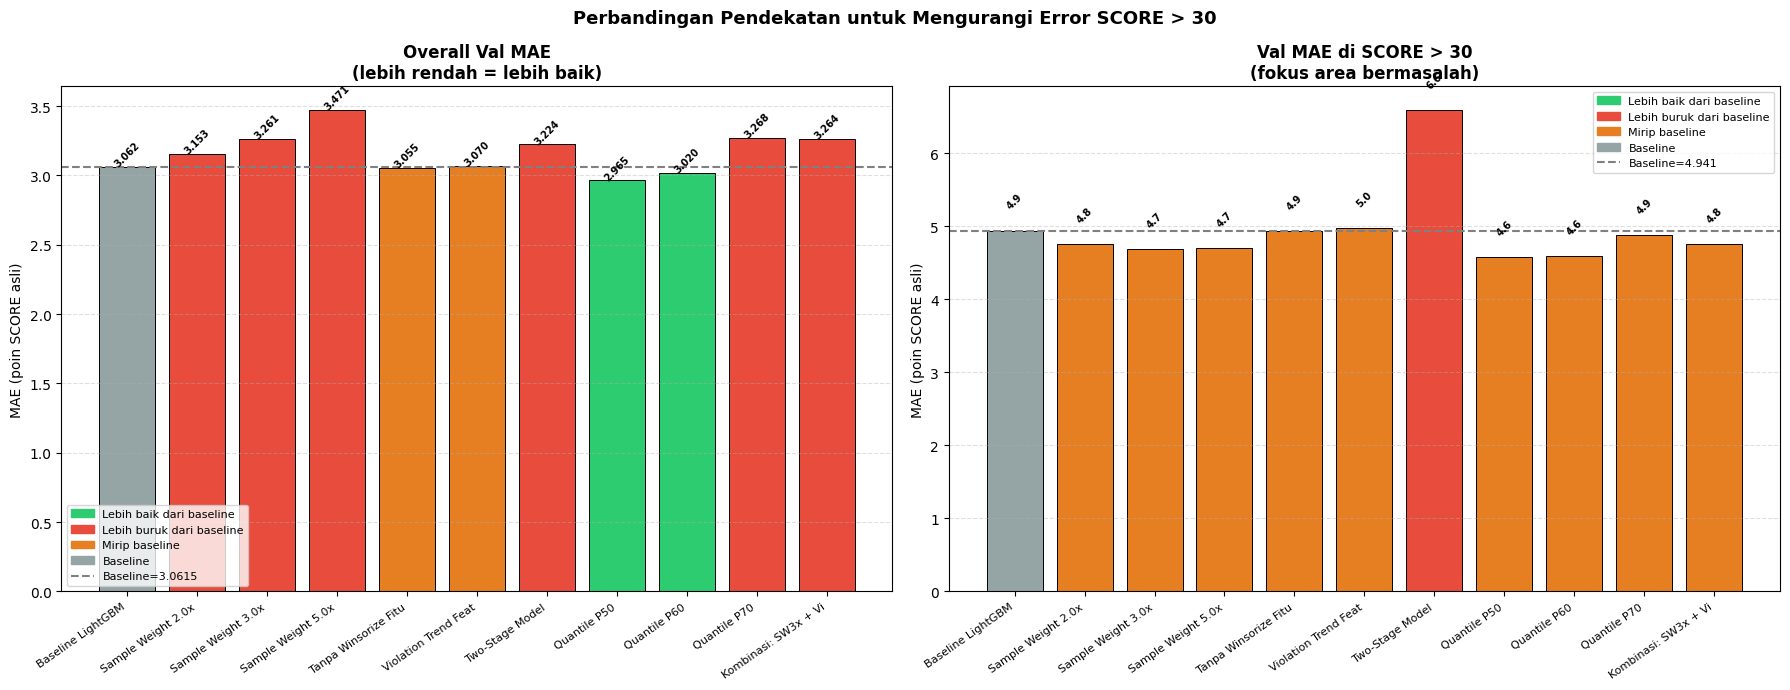

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

models     = [r["model"] for r in experiment_results]

overall    = [r["overall_mae"] for r in experiment_results]

high_mae   = [get_high_mae(r) for r in experiment_results]

x = np.arange(len(models))

baseline_overall = overall[0]

baseline_high_m  = high_mae[0]

colors_o = ["#95a5a6"] + [

    "#2ecc71" if m < baseline_overall - 0.01

    else "#e74c3c" if m > baseline_overall + 0.01

    else "#e67e22"

    for m in overall[1:]

]

colors_h = ["#95a5a6"] + [

    "#2ecc71" if m < baseline_high_m - 1

    else "#e74c3c" if m > baseline_high_m + 1

    else "#e67e22"

    for m in high_mae[1:]

]

bars = axes[0].bar(x, overall, color=colors_o, edgecolor="black", linewidth=0.7)

axes[0].axhline(baseline_overall, color="gray", linestyle="--", linewidth=1.5,

                label=f"Baseline={baseline_overall:.4f}")

for bar, val in zip(bars, overall):

    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.003,

                 f"{val:.3f}", ha="center", fontsize=7, fontweight="bold", rotation=45)

axes[0].set_xticks(x)

axes[0].set_xticklabels([m[:20] for m in models], rotation=35, ha="right", fontsize=8)

axes[0].set_title("Overall Val MAE\n(lebih rendah = lebih baik)",

                  fontsize=12, fontweight="bold")

axes[0].set_ylabel("MAE (poin SCORE asli)")

axes[0].legend(fontsize=9)

axes[0].grid(axis="y", linestyle="--", alpha=0.4)

bars2 = axes[1].bar(x, high_mae, color=colors_h, edgecolor="black", linewidth=0.7)

axes[1].axhline(baseline_high_m, color="gray", linestyle="--", linewidth=1.5,

                label=f"Baseline={baseline_high_m:.3f}")

for bar, val in zip(bars2, high_mae):

    if not np.isnan(val):

        axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3,

                     f"{val:.1f}", ha="center", fontsize=7, fontweight="bold", rotation=45)

axes[1].set_xticks(x)

axes[1].set_xticklabels([m[:20] for m in models], rotation=35, ha="right", fontsize=8)

axes[1].set_title("Val MAE di SCORE > 30\n(fokus area bermasalah)",

                  fontsize=12, fontweight="bold")

axes[1].set_ylabel("MAE (poin SCORE asli)")

axes[1].legend(fontsize=9)

axes[1].grid(axis="y", linestyle="--", alpha=0.4)

from matplotlib.patches import Patch

for ax in axes:

    ax.legend(handles=[

        Patch(color="#2ecc71", label="Lebih baik dari baseline"),

        Patch(color="#e74c3c", label="Lebih buruk dari baseline"),

        Patch(color="#e67e22", label="Mirip baseline"),

        Patch(color="#95a5a6", label="Baseline"),

    ] + ax.get_legend_handles_labels()[0], fontsize=8)

plt.suptitle("Perbandingan Pendekatan untuk Mengurangi Error SCORE > 30",

             fontsize=13, fontweight="bold")

plt.tight_layout()

plt.show()

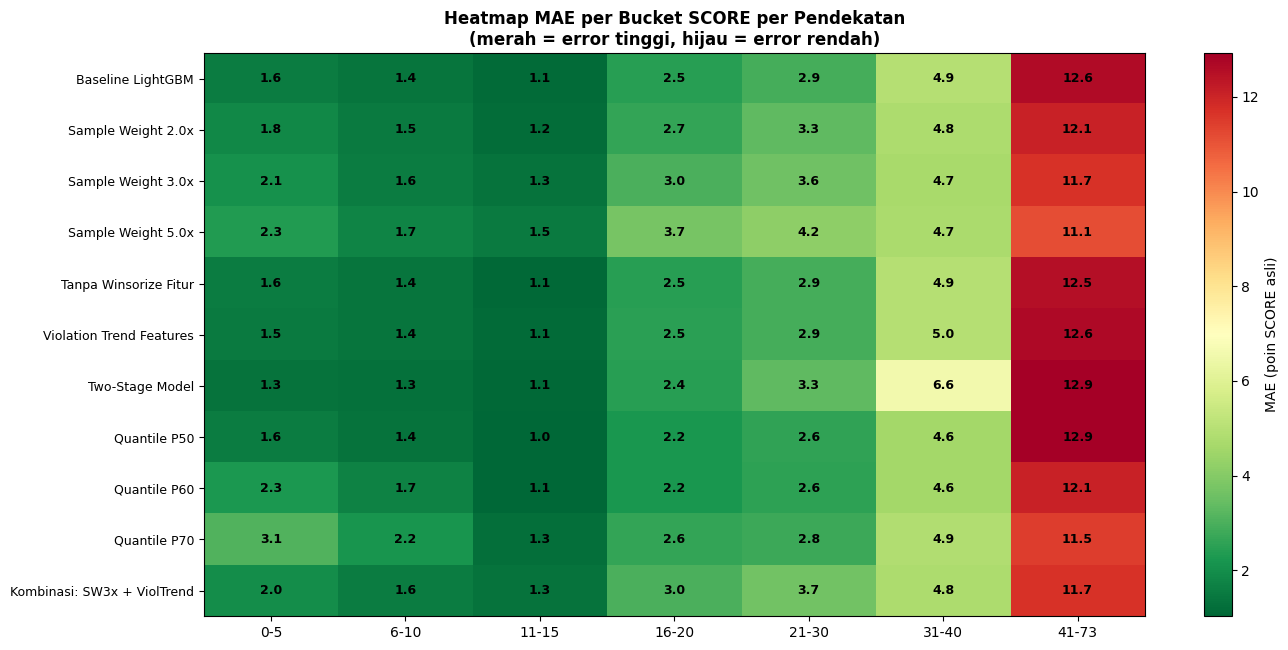

In [73]:
bucket_labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]

heatmap_data  = []

for res in experiment_results:

    row = {"model": res["model"]}

    bucket_dict = {r["bucket"]: r["mae"] for r in res["bucket_results"]}

    for b in bucket_labels:

        row[b] = bucket_dict.get(b, np.nan)

    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data).set_index("model")

fig, ax = plt.subplots(figsize=(14, max(6, len(experiment_results) * 0.6)))

im = ax.imshow(df_heat.values.astype(float), cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(bucket_labels)))

ax.set_xticklabels(bucket_labels, fontsize=10)

ax.set_yticks(range(len(heatmap_data)))

ax.set_yticklabels([r["model"] for r in experiment_results], fontsize=9)

for i in range(len(heatmap_data)):

    for j in range(len(bucket_labels)):

        val = df_heat.values[i, j]

        if not np.isnan(val):

            ax.text(j, i, f"{val:.1f}", ha="center", va="center",

                    fontsize=9, fontweight="bold",

                    color="white" if val > 15 else "black")

plt.colorbar(im, ax=ax, label="MAE (poin SCORE asli)")

ax.set_title("Heatmap MAE per Bucket SCORE per Pendekatan\n"

             "(merah = error tinggi, hijau = error rendah)",

             fontsize=12, fontweight="bold")

plt.tight_layout()

plt.show()

## Kesimpulan & Rekomendasi ##

In [74]:
print("=" * 70)

print("  KESIMPULAN EKSPERIMEN")

print("=" * 70)

best_overall = min(experiment_results[1:], key=lambda x: x["overall_mae"])

best_high    = min(

    [r for r in experiment_results[1:] if not np.isnan(get_high_mae(r))],

    key=lambda x: get_high_mae(x)

)

print(f"\nPendekatan terbaik untuk OVERALL MAE:")

print(f"  {best_overall['model']}")

print(f"  MAE = {best_overall['overall_mae']:.4f} "

      f"(vs baseline {baseline_mae:.4f}, "

      f"delta={best_overall['overall_mae']-baseline_mae:+.4f})")

print(f"\nPendekatan terbaik untuk MAE di SCORE > 30:")

print(f"  {best_high['model']}")

print(f"  MAE = {get_high_mae(best_high):.3f} "

      f"(vs baseline {baseline_high_m:.3f}, "

      f"delta={get_high_mae(best_high)-baseline_high_m:+.3f})")

print()


  KESIMPULAN EKSPERIMEN

Pendekatan terbaik untuk OVERALL MAE:
  Quantile P50
  MAE = 2.9648 (vs baseline 3.0615, delta=-0.0967)

Pendekatan terbaik untuk MAE di SCORE > 30:
  Quantile P50
  MAE = 4.582 (vs baseline 4.941, delta=-0.359)



# Tambahan Eksperimen — Error Reduction

Bagian ini digabung dari `error_reduction.ipynb` dan diasumsikan dijalankan **setelah** seluruh notebook eksperimen utama selesai dijalankan, karena menggunakan variabel seperti `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `df_base`, `df_ins`, `study_xgb`, `study_lgb`, `study_cat`, dan `cat_tuned`.


# Error Reduction untuk High-Score Range

## Konteks Masalah
Dari error analysis sebelumnya:
| Rentang SCORE | MAE | Masalah |
|---|---|---|
| 0–5 | 1.51 | ✅ Normal |
| 6–10 | 1.35 | ✅ Normal |
| 11–15 | 1.12 | ✅ Normal |
| 16–20 | 2.47 | ⚠️ Mulai naik |
| 21–30 | 2.70 | ⚠️ Tinggi |
| 31–40 | 5.08 | 🔴 Sangat tinggi |
| **41–73** | **13.44** | 🚨 Kritis — underprediksi sistematis |

## Strategi yang Diimplementasikan
1. **Sample Weighting** — beri bobot lebih besar ke sampel high-score
2. **Custom Loss Function** — Asymmetric/Huber loss di XGBoost & LightGBM
3. **Two-Stage Model** — klasifikasi high/low risk dulu, lalu regresi
4. **Separate Model per Score Bucket** — model khusus untuk SCORE > 30
5. **Improved Feature Engineering** — flag compliance & pre-permit non-op
6. **Quantile Regression** — prediksi upper quantile untuk high-risk

In [75]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import RobustScaler

import xgboost as xgb

import lightgbm as lgb

from catboost import CatBoostRegressor

print('✅ Library berhasil di-import')

print(f'XGBoost  : {xgb.__version__}')

print(f'LightGBM : {lgb.__version__}')

✅ Library berhasil di-import
XGBoost  : 3.1.2
LightGBM : 4.6.0


## Fungsi Helper

In [76]:
def evaluate_with_buckets(y_actual_log, y_pred_log, model_name='Model'):

    """Evaluasi model + breakdown per score bucket (skala asli)."""

    y_a = np.expm1(y_actual_log)

    y_p = np.expm1(y_pred_log)

    abs_err = np.abs(y_a - y_p)

    overall_mae  = mean_absolute_error(y_a, y_p)

    overall_rmse = np.sqrt(mean_squared_error(y_actual_log, y_pred_log))

    overall_r2   = r2_score(y_actual_log, y_pred_log)

    print(f'\n{"="*55}')

    print(f'  {model_name}')

    print(f'{"="*55}')

    print(f'  Overall R²   : {overall_r2:.4f}')

    print(f'  Overall RMSE : {overall_rmse:.4f}  (log1p scale)')

    print(f'  Overall MAE  : {overall_mae:.4f}  (skala SCORE asli)')

    bins   = [0, 5, 10, 15, 20, 30, 40, 75]

    labels = ['0–5', '6–10', '11–15', '16–20', '21–30', '31–40', '41–73']

    bucket = pd.cut(y_a, bins=bins, labels=labels, right=True, include_lowest=True)

    print(f'\n  MAE per rentang SCORE:')

    bucket_mae = {}

    for lbl in labels:

        mask = bucket == lbl

        if mask.sum() == 0:

            continue

        mae_b = abs_err[mask].mean()

        bucket_mae[lbl] = mae_b

        flag = ' 🚨' if mae_b > 10 else ' ⚠️' if mae_b > 5 else ' ✅'

        print(f'    {lbl:>7} : {mae_b:6.2f}  (n={mask.sum():4d}){flag}')

    return overall_mae, overall_r2, bucket_mae

def plot_error_comparison(results_dict, title='Perbandingan MAE per Bucket'):


    labels = ['0–5', '6–10', '11–15', '16–20', '21–30', '31–40', '41–73']

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    x = np.arange(len(labels))

    width = 0.8 / max(len(results_dict), 1)

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']

    for i, (name, (mae_overall, r2, bucket_mae)) in enumerate(results_dict.items()):

        maes = [bucket_mae.get(lbl, np.nan) for lbl in labels]

        offset = (i - len(results_dict)/2 + 0.5) * width

        axes[0].bar(x + offset, maes, width, label=name,

                    color=colors[i % len(colors)], edgecolor='black', linewidth=0.5, alpha=0.85)

    axes[0].set_xticks(x)

    axes[0].set_xticklabels(labels)

    axes[0].set_title('MAE per Rentang SCORE', fontsize=12, fontweight='bold')

    axes[0].set_xlabel('Rentang SCORE Aktual')

    axes[0].set_ylabel('MAE (poin SCORE)')

    axes[0].legend(fontsize=8)

    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    names  = list(results_dict.keys())

    maes_o = [v[0] for v in results_dict.values()]

    r2s    = [v[1] for v in results_dict.values()]

    bar_colors = [colors[i % len(colors)] for i in range(len(names))]

    bars = axes[1].bar(names, maes_o, color=bar_colors, edgecolor='black', linewidth=0.7, alpha=0.85)

    for bar, val, r2 in zip(bars, maes_o, r2s):

        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03,

                     f'MAE={val:.2f}\nR²={r2:.4f}', ha='center', fontsize=8, fontweight='bold')

    axes[1].set_title('Overall MAE & R²', fontsize=12, fontweight='bold')

    axes[1].set_ylabel('Overall MAE (poin SCORE)')

    axes[1].tick_params(axis='x', rotation=20)

    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout()

    plt.show()

print('✅ Helper functions siap')

✅ Helper functions siap


In [77]:
import pickle
with open("./Tempat kerja Hubert/models/tuned_models.pkl", "rb") as f:
    saved = pickle.load(f)

rf_tuned      = saved["rf_tuned"]
xgb_tuned     = saved["xgb_tuned"]
lgb_tuned     = saved["lgb_tuned"]
cat_tuned     = saved["cat_tuned"]
tuned_results = saved["tuned_results"]
print("✅ Di-load")

✅ Di-load


## Baseline — Performa CatBoost Sebelumnya

In [78]:
X_test_base = X_test.copy()

if hasattr(cat_tuned, 'feature_names_in_'):

    X_test_base.columns = cat_tuned.feature_names_in_

y_pred_baseline = cat_tuned.predict(X_test_base)

baseline_mae, baseline_r2, baseline_bucket = evaluate_with_buckets(

    y_test.values, y_pred_baseline, 'Baseline: CatBoost (Tuned)'

)

all_results = {

    'Baseline\nCatBoost': (baseline_mae, baseline_r2, baseline_bucket)

}


  Baseline: CatBoost (Tuned)
  Overall R²   : 0.8533
  Overall RMSE : 0.2911  (log1p scale)
  Overall MAE  : 2.9090  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   1.51  (n=1178) ✅
       6–10 :   1.35  (n=1426) ✅
      11–15 :   1.13  (n=3523) ✅
      16–20 :   2.39  (n= 695) ✅
      21–30 :   2.75  (n=1850) ✅
      31–40 :   5.10  (n= 785) ⚠️
      41–73 :  13.36  (n= 872) 🚨


---
# Metode 1 — Feature Engineering: Flag Compliance & Pre-permit Non-Op

**Hipotesis:** Model tidak tahu bahwa `Pre-permit Non-operational` adalah kondisi khusus
(restoran baru, tidak punya riwayat, dan score cenderung sangat tinggi). Dengan menambahkan
flag eksplisit untuk tipe-tipe ini, model mendapat sinyal langsung tentang distribusi SCORE
yang berbeda.

In [79]:
def add_risk_flags(X_df, df_ids_slice, df_ins_ref):

    X_out = X_df.copy()

    ref = df_ins_ref[['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE']].copy()

    ref['CAMIS'] = ref['CAMIS'].astype(str)

    ref['INSPECTION DATE'] = pd.to_datetime(ref['INSPECTION DATE'])

    ids = df_ids_slice.copy()

    ids['CAMIS'] = ids['CAMIS'].astype(str)

    ids['INSPECTION DATE'] = pd.to_datetime(ids['INSPECTION DATE'])

    ids = ids.reset_index(drop=True)

    merged = ids.merge(

        ref[['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE']].drop_duplicates(),

        on=['CAMIS', 'INSPECTION DATE'],

        how='left'

    )

    ins_types = merged['INSPECTION TYPE'].astype('string').fillna('')

    X_out['is_non_op'] = ins_types.str.contains('Non-operational', case=False, na=False).astype(int).values

    X_out['is_compliance'] = ins_types.str.contains('Compliance', case=False, na=False).astype(int).values

    X_out['is_prepermit'] = ins_types.str.contains('Pre-permit', case=False, na=False).astype(int).values

    X_out['is_reopening'] = ins_types.str.contains('Reopening', case=False, na=False).astype(int).values

    print(f'  is_non_op     : {X_out["is_non_op"].sum()} sampel')

    print(f'  is_compliance : {X_out["is_compliance"].sum()} sampel')

    print(f'  is_prepermit  : {X_out["is_prepermit"].sum()} sampel')

    print(f'  is_reopening  : {X_out["is_reopening"].sum()} sampel')

    return X_out

n_base = len(df_base)

train_end = int(n_base * 0.70)

val_end = int(n_base * 0.85)

df_ids_sorted = df_base[['CAMIS', 'INSPECTION DATE']].copy()

df_ids_sorted['INSPECTION DATE'] = pd.to_datetime(df_ids_sorted['INSPECTION DATE'])

df_ids_sorted = df_ids_sorted.sort_values('INSPECTION DATE').reset_index(drop=True)

ids_train = df_ids_sorted.iloc[:train_end].copy().reset_index(drop=True)

ids_val = df_ids_sorted.iloc[train_end:val_end].copy().reset_index(drop=True)

ids_test = df_ids_sorted.iloc[val_end:].copy().reset_index(drop=True)

print('Menambahkan risk flags...')

print('TRAIN:')

X_train_f1 = add_risk_flags(X_train.reset_index(drop=True), ids_train, df_ins)

print('VAL:')

X_val_f1 = add_risk_flags(X_val.reset_index(drop=True), ids_val, df_ins)

print('TEST:')

X_test_f1 = add_risk_flags(X_test.reset_index(drop=True), ids_test, df_ins)

print(f'\nFitur baru: {[c for c in X_train_f1.columns if c not in X_train.columns]}')

print(f'Total fitur: {X_train_f1.shape[1]}')

Menambahkan risk flags...
TRAIN:
  is_non_op     : 782 sampel
  is_compliance : 573 sampel
  is_prepermit  : 10320 sampel
  is_reopening  : 951 sampel
VAL:
  is_non_op     : 226 sampel
  is_compliance : 128 sampel
  is_prepermit  : 1355 sampel
  is_reopening  : 270 sampel
TEST:
  is_non_op     : 151 sampel
  is_compliance : 102 sampel
  is_prepermit  : 2453 sampel
  is_reopening  : 195 sampel

Fitur baru: ['is_non_op', 'is_compliance', 'is_prepermit', 'is_reopening']
Total fitur: 40


In [80]:
cat_params = cat_tuned.get_params().copy()
for k in ["bootstrap_type", "task_type", "devices", "random_seed", "verbose"]:
    cat_params.pop(k, None)

cat_f1 = CatBoostRegressor(
    **cat_params,
    bootstrap_type='Poisson',
    task_type='GPU',
    devices='0',
    random_seed=42,
    verbose=0
)

cat_f1.fit(

    X_train_f1, y_train,

    eval_set=(X_val_f1, y_val),

    early_stopping_rounds=30,

    verbose=0

)

y_pred_f1 = cat_f1.predict(X_test_f1)

mae_f1, r2_f1, bucket_f1 = evaluate_with_buckets(

    y_test.values, y_pred_f1, 'Metode 1: CatBoost + Risk Flags'

)

all_results['M1: +Risk\nFlags'] = (mae_f1, r2_f1, bucket_f1)


  Metode 1: CatBoost + Risk Flags
  Overall R²   : 0.8778
  Overall RMSE : 0.2656  (log1p scale)
  Overall MAE  : 2.8813  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   1.29  (n=1178) ✅
       6–10 :   1.42  (n=1426) ✅
      11–15 :   1.16  (n=3523) ✅
      16–20 :   2.35  (n= 695) ✅
      21–30 :   2.71  (n=1850) ✅
      31–40 :   5.08  (n= 785) ⚠️
      41–73 :  13.18  (n= 872) 🚨


---
# Metode 2 — Sample Weighting

**Hipotesis:** Model belajar dengan bobot seragam sehingga lebih fokus meminimalkan error
di sampel mayoritas (SCORE 6–20). Dengan memberi **bobot lebih tinggi ke sampel high-score**,
model dipaksa lebih memperhatikan rentang tersebut.

Distribusi sample weights:
1.0    33179
2.0     7928
3.0     3239
5.0     3856
Name: count, dtype: int64

Rentang weight: [1.00, 5.00]


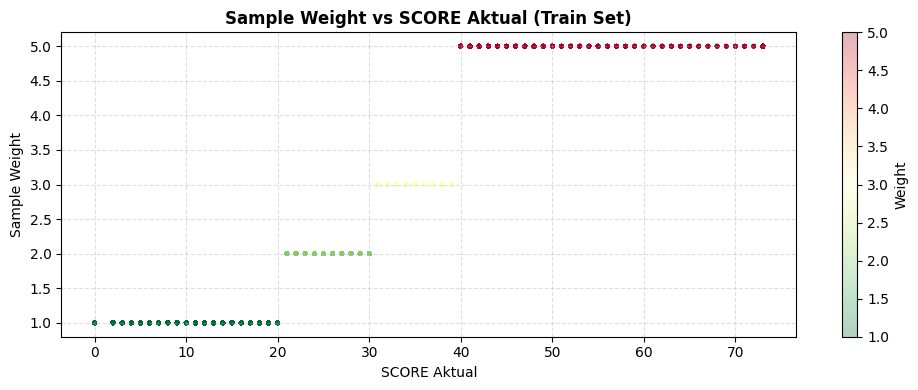

In [81]:
def compute_sample_weights(y_log, strategy='sqrt_score', scale_factor=3.0):


    score_orig = np.expm1(y_log)

    max_score  = score_orig.max()

    if strategy == 'sqrt_score':

        weights = 1 + np.sqrt(score_orig / max_score) * scale_factor

    elif strategy == 'linear_score':

        weights = 1 + (score_orig / max_score) * scale_factor

    elif strategy == 'bucket':

        weights = np.ones(len(score_orig))

        weights[score_orig > 40] = 5.0

        weights[(score_orig > 30) & (score_orig <= 40)] = 3.0

        weights[(score_orig > 20) & (score_orig <= 30)] = 2.0

    else:

        weights = np.ones(len(score_orig))

    return weights

sample_weights = compute_sample_weights(y_train.values, strategy='bucket')

print('Distribusi sample weights:')

print(pd.Series(sample_weights).value_counts().sort_index())

print(f'\nRentang weight: [{sample_weights.min():.2f}, {sample_weights.max():.2f}]')

fig, ax = plt.subplots(figsize=(10, 4))

score_orig_train = np.expm1(y_train.values)

scatter = ax.scatter(score_orig_train, sample_weights,

                     c=sample_weights, cmap='RdYlGn_r',

                     alpha=0.3, s=5)

plt.colorbar(scatter, label='Weight')

ax.set_xlabel('SCORE Aktual')

ax.set_ylabel('Sample Weight')

ax.set_title('Sample Weight vs SCORE Aktual (Train Set)', fontweight='bold')

ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

In [82]:

xgb_tuned.fit(

    X_train, y_train,

    sample_weight=sample_weights,

    eval_set=[(X_val, y_val)],

    verbose=False

)

y_pred_sw = xgb_tuned.predict(X_test)

mae_sw, r2_sw, bucket_sw = evaluate_with_buckets(

    y_test.values, y_pred_sw, 'Metode 2a: XGBoost + Sample Weight (bucket)'

)

all_results['M2a: Sample\nWeight (XGB)'] = (mae_sw, r2_sw, bucket_sw)


  Metode 2a: XGBoost + Sample Weight (bucket)
  Overall R²   : 0.8319
  Overall RMSE : 0.3116  (log1p scale)
  Overall MAE  : 3.2393  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.34  (n=1178) ✅
       6–10 :   1.65  (n=1426) ✅
      11–15 :   1.42  (n=3523) ✅
      16–20 :   3.40  (n= 695) ✅
      21–30 :   3.51  (n=1850) ✅
      31–40 :   5.30  (n= 785) ⚠️
      41–73 :  11.84  (n= 872) 🚨


In [83]:
sample_weights_sqrt = compute_sample_weights(y_train.values, strategy='sqrt_score', scale_factor=4.0)

lgb_tuned.fit(

    X_train, y_train,

    sample_weight=sample_weights_sqrt,

    eval_set=[(X_val, y_val)],

    callbacks=[

        lgb.early_stopping(30, verbose=False),

        lgb.log_evaluation(period=-1)

    ]

)

y_pred_lgb_sw = lgb_tuned.predict(X_test)

mae_lgb_sw, r2_lgb_sw, bucket_lgb_sw = evaluate_with_buckets(

    y_test.values, y_pred_lgb_sw, 'Metode 2b: LightGBM + Sample Weight (sqrt)'

)

all_results['M2b: Sample\nWeight (LGB)'] = (mae_lgb_sw, r2_lgb_sw, bucket_lgb_sw)


  Metode 2b: LightGBM + Sample Weight (sqrt)
  Overall R²   : 0.8440
  Overall RMSE : 0.3002  (log1p scale)
  Overall MAE  : 2.9870  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.11  (n=1178) ✅
       6–10 :   1.53  (n=1426) ✅
      11–15 :   1.17  (n=3523) ✅
      16–20 :   2.53  (n= 695) ✅
      21–30 :   2.82  (n=1850) ✅
      31–40 :   5.16  (n= 785) ⚠️
      41–73 :  12.67  (n= 872) 🚨


---
# Metode 3 — Custom Loss: Asymmetric MAE

**Hipotesis:** Standard MAE/MSE menghukur error ke atas dan ke bawah sama berat.
Karena model sistematis **underprediksi** (actual > pred) di high-score,
kita bisa pakai **Asymmetric Loss** yang menghukum underprediksi lebih berat.

In [84]:
def asymmetric_mae_obj(alpha=2.0):


    def obj(y_pred, dtrain):

        y_true = dtrain.get_label()

        residual = y_true - y_pred

        grad = np.where(residual > 0, -alpha, 1.0)

        hess = np.ones_like(grad)

        return grad, hess

    return obj

def asymmetric_mae_eval(alpha=2.0):

    """Custom eval metric untuk asymmetric MAE."""

    def eval_fn(y_pred, dtrain):

        y_true = dtrain.get_label()

        residual = y_true - y_pred

        loss = np.where(residual > 0, alpha * np.abs(residual), np.abs(residual))

        return 'asym_mae', float(loss.mean())

    return eval_fn

params_xgb_base = {
    xgb_tuned.get_params().get('objective', 'reg:squarederror'),

}

dtrain = xgb.DMatrix(X_train, label=y_train)

dval   = xgb.DMatrix(X_val,   label=y_val)

dtest  = xgb.DMatrix(X_test)

ALPHA_ASYM = 3.0

xgb_asym = xgb.train(
    params = xgb_tuned.get_params(),
    dtrain   = dtrain,

    num_boost_round = xgb_tuned.get_params().get('n_estimators', 300),

    obj      = asymmetric_mae_obj(alpha=ALPHA_ASYM),

    custom_metric = asymmetric_mae_eval(alpha=ALPHA_ASYM),

    evals    = [(dval, 'val')],

    early_stopping_rounds = 30,

    verbose_eval = False

)

y_pred_asym = xgb_asym.predict(dtest)

mae_asym, r2_asym, bucket_asym = evaluate_with_buckets(

    y_test.values, y_pred_asym, f'Metode 3: XGBoost Asymmetric Loss (α={ALPHA_ASYM})'

)

all_results[f'M3: Asym\nLoss (α={ALPHA_ASYM})'] = (mae_asym, r2_asym, bucket_asym)


  Metode 3: XGBoost Asymmetric Loss (α=3.0)
  Overall R²   : 0.8121
  Overall RMSE : 0.3293  (log1p scale)
  Overall MAE  : 3.3385  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.96  (n=1178) ✅
       6–10 :   2.26  (n=1426) ✅
      11–15 :   1.28  (n=3523) ✅
      16–20 :   3.07  (n= 695) ✅
      21–30 :   3.14  (n=1850) ✅
      31–40 :   5.69  (n= 785) ⚠️
      41–73 :  12.47  (n= 872) 🚨


---
# Metode 4 — Separate Model untuk High-Score

**Hipotesis:** Distribusi SCORE > 30 sangat berbeda — lebih sparse, lebih banyak noise.
Daripada satu model untuk semua, kita buat:
1. **Classifier** → prediksi apakah SCORE > 30 atau tidak
2. **Model rendah** → untuk SCORE yang diprediksi ≤ 30
3. **Model tinggi** → untuk SCORE yang diprediksi > 30

In [85]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import GradientBoostingClassifier

HIGH_SCORE_THRESHOLD = np.log1p(30)

y_train_high = (y_train > HIGH_SCORE_THRESHOLD).astype(int)

y_val_high   = (y_val   > HIGH_SCORE_THRESHOLD).astype(int)

y_test_high  = (y_test  > HIGH_SCORE_THRESHOLD).astype(int)

print(f'Threshold log1p: {HIGH_SCORE_THRESHOLD:.3f} ≈ SCORE {np.expm1(HIGH_SCORE_THRESHOLD):.0f}')

print(f'Train — Low: {(~y_train_high.astype(bool)).sum():,}  High: {y_train_high.sum():,} ({y_train_high.mean()*100:.1f}%)')

print(f'Val   — Low: {(~y_val_high.astype(bool)).sum():,}  High: {y_val_high.sum():,} ({y_val_high.mean()*100:.1f}%)')

print(f'Test  — Low: {(~y_test_high.astype(bool)).sum():,}  High: {y_test_high.sum():,} ({y_test_high.mean()*100:.1f}%)')

clf = xgb.XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=(~y_train_high.astype(bool)).sum() / y_train_high.sum(),

    device='cuda:0',

    random_state=42,

    n_jobs=-1,

    verbosity=0,

    early_stopping_rounds=30,

    eval_metric='logloss'

)

clf.fit(X_train, y_train_high, eval_set=[(X_val, y_val_high)], verbose=False)

from sklearn.metrics import classification_report

y_val_pred_clf = clf.predict(X_val)

y_test_pred_clf = clf.predict(X_test)

y_test_prob_clf = clf.predict_proba(X_test)[:, 1]

print('\n── Evaluasi Classifier (Val Set) ──')

print(classification_report(y_val_high, y_val_pred_clf, target_names=['Low (≤30)', 'High (>30)']))

Threshold log1p: 3.434 ≈ SCORE 30
Train — Low: 41,107  High: 7,095 (14.7%)
Val   — Low: 8,514  High: 1,815 (17.6%)
Test  — Low: 8,672  High: 1,657 (16.0%)

── Evaluasi Classifier (Val Set) ──
              precision    recall  f1-score   support

   Low (≤30)       0.98      0.92      0.95      8514
  High (>30)       0.69      0.90      0.78      1815

    accuracy                           0.91     10329
   macro avg       0.84      0.91      0.86     10329
weighted avg       0.93      0.91      0.92     10329



In [86]:
mask_high_train = y_train > HIGH_SCORE_THRESHOLD

mask_low_train  = ~mask_high_train

mask_high_val   = y_val > HIGH_SCORE_THRESHOLD

print(f'Model Rendah — train: {mask_low_train.sum():,} sampel')

print(f'Model Tinggi — train: {mask_high_train.sum():,} sampel')


cat_tuned.fit(

    X_train[mask_low_train], y_train[mask_low_train],

    eval_set=(X_val[mask_high_val == False], y_val[mask_high_val == False]),

    early_stopping_rounds=30, verbose=0

)

y_train_high_vals = y_train[mask_high_train]

sw_high = compute_sample_weights(y_train_high_vals.values, strategy='sqrt_score', scale_factor=2.0)

cat_high = CatBoostRegressor(

    iterations=500,

    learning_rate=0.03,

    depth=6,

    l2_leaf_reg=5.0,

    subsample=0.8,

    bootstrap_type='Poisson',

    task_type='GPU', devices='0',

    random_seed=42, verbose=0

)

cat_high.fit(

    X_train[mask_high_train], y_train_high_vals,

    sample_weight=sw_high,

    verbose=0

)

print('\n✅ Kedua model regresi terlatih')

print(f'Model Rendah — best iter: {cat_tuned.get_best_iteration()}')

print(f'Model Tinggi — iterations: {cat_high.get_best_iteration()}')

Model Rendah — train: 41,107 sampel
Model Tinggi — train: 7,095 sampel

✅ Kedua model regresi terlatih
Model Rendah — best iter: 181
Model Tinggi — iterations: None


In [87]:
y_pred_low_test  = cat_tuned.predict(X_test)

y_pred_high_test = cat_high.predict(X_test)

prob_high = y_test_prob_clf

y_pred_m4_soft = (1 - prob_high) * y_pred_low_test + prob_high * y_pred_high_test

PROB_THRESHOLD = 0.5

y_pred_m4_hard = np.where(prob_high > PROB_THRESHOLD, y_pred_high_test, y_pred_low_test)

print('── Soft Routing ──')

mae_m4s, r2_m4s, bucket_m4s = evaluate_with_buckets(

    y_test.values, y_pred_m4_soft, 'Metode 4a: Two-Stage (Soft Routing)'

)

all_results['M4a: Two-Stage\n(Soft)'] = (mae_m4s, r2_m4s, bucket_m4s)

print('\n── Hard Routing ──')

mae_m4h, r2_m4h, bucket_m4h = evaluate_with_buckets(

    y_test.values, y_pred_m4_hard, 'Metode 4b: Two-Stage (Hard Routing)'

)

all_results['M4b: Two-Stage\n(Hard)'] = (mae_m4h, r2_m4h, bucket_m4h)

── Soft Routing ──

  Metode 4a: Two-Stage (Soft Routing)
  Overall R²   : 0.8239
  Overall RMSE : 0.3189  (log1p scale)
  Overall MAE  : 3.4417  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.44  (n=1178) ✅
       6–10 :   1.66  (n=1426) ✅
      11–15 :   1.54  (n=3523) ✅
      16–20 :   3.30  (n= 695) ✅
      21–30 :   4.46  (n=1850) ✅
      31–40 :   5.52  (n= 785) ⚠️
      41–73 :  11.49  (n= 872) 🚨

── Hard Routing ──

  Metode 4b: Two-Stage (Hard Routing)
  Overall R²   : 0.7709
  Overall RMSE : 0.3637  (log1p scale)
  Overall MAE  : 3.7381  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   3.46  (n=1178) ✅
       6–10 :   1.82  (n=1426) ✅
      11–15 :   1.40  (n=3523) ✅
      16–20 :   3.42  (n= 695) ✅
      21–30 :   5.60  (n=1850) ⚠️
      31–40 :   6.77  (n= 785) ⚠️
      41–73 :  10.26  (n= 872) 🚨


---
# Metode 5 — Huber Loss + Score-Focused Features

**Hipotesis:** MSE sangat sensitif terhadap outlier (mendominasi gradient).
**Huber loss** lebih robust — berperilaku seperti MSE di dekat 0 dan MAE di jauh dari 0.

In [88]:
xgb_huber = xgb.XGBRegressor(
    
    params = xgb_tuned.get_params(),

    objective='reg:pseudohubererror',

    huber_slope=1.0,

    eval_metric='mae',

    early_stopping_rounds=30,

    device='cuda:0',

    random_state=42,

    n_jobs=-1,

    verbosity=0

)

xgb_huber.fit(

    X_train, y_train,

    eval_set=[(X_val, y_val)],

    verbose=False

)

print(f'Best iteration: {xgb_huber.best_iteration}')

y_pred_huber = xgb_huber.predict(X_test)

mae_huber, r2_huber, bucket_huber = evaluate_with_buckets(

    y_test.values, y_pred_huber, 'Metode 5: XGBoost Huber Loss'

)

all_results['M5: Huber\nLoss'] = (mae_huber, r2_huber, bucket_huber)

Best iteration: 0

  Metode 5: XGBoost Huber Loss
  Overall R²   : -95262.6283
  Overall RMSE : 234.5204  (log1p scale)
  Overall MAE  : 19.3191  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   4.08  (n=1178) ✅
       6–10 :   8.81  (n=1426) ⚠️
      11–15 :  12.80  (n=3523) 🚨
      16–20 :  19.55  (n= 695) 🚨
      21–30 :  26.13  (n=1850) 🚨
      31–40 :  35.44  (n= 785) 🚨
      41–73 :  54.27  (n= 872) 🚨


In [89]:
lgb_huber = lgb.LGBMRegressor(

    objective='huber',

    alpha=0.9,

    random_state=42,

    n_jobs=-1,

    verbose=-1

)

lgb_huber.fit(

    X_train, y_train,

    eval_set=[(X_val, y_val)],

    callbacks=[

        lgb.early_stopping(30, verbose=False),

        lgb.log_evaluation(period=-1)

    ]

)

print(f'Best iteration: {lgb_huber.best_iteration_}')

y_pred_lgb_hub = lgb_huber.predict(X_test)

mae_lgb_hub, r2_lgb_hub, bucket_lgb_hub = evaluate_with_buckets(

    y_test.values, y_pred_lgb_hub, 'Metode 5b: LightGBM Huber (alpha=0.9)'

)

all_results['M5b: LGB\nHuber'] = (mae_lgb_hub, r2_lgb_hub, bucket_lgb_hub)

Best iteration: 92

  Metode 5b: LightGBM Huber (alpha=0.9)
  Overall R²   : 0.8534
  Overall RMSE : 0.2910  (log1p scale)
  Overall MAE  : 2.9107  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   1.65  (n=1178) ✅
       6–10 :   1.39  (n=1426) ✅
      11–15 :   1.08  (n=3523) ✅
      16–20 :   2.53  (n= 695) ✅
      21–30 :   2.76  (n=1850) ✅
      31–40 :   5.13  (n= 785) ⚠️
      41–73 :  13.13  (n= 872) 🚨


---
# Metode 6 — Quantile Regression sebagai Upper Bound

**Hipotesis:** Untuk inspeksi berisiko tinggi, lebih baik sedikit *overprediksi*
daripada *underprediksi* (false safety). Kita bisa prediksi **quantile 0.7–0.8**
sehingga prediksi sedikit lebih konservatif (lebih tinggi dari median).

In [90]:
from sklearn.linear_model import QuantileRegressor

QUANTILE = 0.7

lgb_params = lgb_tuned.get_params().copy()
for k in ["bootstrap_type", "task_type", "devices", "random_seed", "verbose", "objective", "alpha", "random_state", "n_jobs"]:
    lgb_params.pop(k, None)

lgb_q70 = lgb.LGBMRegressor(

    **lgb_params,

    objective='quantile',

    alpha=QUANTILE,

    random_state=42,

    n_jobs=-1,

    verbose=-1

)

lgb_q70.fit(

    X_train, y_train,

    eval_set=[(X_val, y_val)],

    callbacks=[

        lgb.early_stopping(30, verbose=False),

        lgb.log_evaluation(period=-1)

    ]

)

y_pred_q70 = lgb_q70.predict(X_test)

mae_q70, r2_q70, bucket_q70 = evaluate_with_buckets(

    y_test.values, y_pred_q70, f'Metode 6: Quantile Regression Q{int(QUANTILE*100)}'

)

all_results[f'M6: Quantile\nQ{int(QUANTILE*100)}'] = (mae_q70, r2_q70, bucket_q70)


  Metode 6: Quantile Regression Q70
  Overall R²   : 0.8128
  Overall RMSE : 0.3288  (log1p scale)
  Overall MAE  : 3.1665  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.90  (n=1178) ✅
       6–10 :   2.13  (n=1426) ✅
      11–15 :   1.20  (n=3523) ✅
      16–20 :   2.67  (n= 695) ✅
      21–30 :   2.79  (n=1850) ✅
      31–40 :   5.33  (n= 785) ⚠️
      41–73 :  12.41  (n= 872) 🚨


---
# Metode 7 — Blending: Median Model + High-Score Specialist

**Hipotesis:** Gunakan model umum untuk prediksi normal, tapi saat probabilitas high-score tinggi,
blend dengan quantile model. Ini memberi kita **prediksi yang lebih conservative** hanya
saat diperlukan.

In [91]:
y_pred_cat  = cat_tuned.predict(X_test_base)

y_pred_q70t = lgb_q70.predict(X_test)

BLEND_SCALE = 1.5

alpha_blend = np.clip(prob_high * BLEND_SCALE, 0, 1)

y_pred_blend = (1 - alpha_blend) * y_pred_cat + alpha_blend * y_pred_q70t

mae_blend, r2_blend, bucket_blend = evaluate_with_buckets(

    y_test.values, y_pred_blend, 'Metode 7: Adaptive Blend (Baseline + Quantile)'

)

all_results['M7: Adaptive\nBlend'] = (mae_blend, r2_blend, bucket_blend)


  Metode 7: Adaptive Blend (Baseline + Quantile)
  Overall R²   : 0.8385
  Overall RMSE : 0.3053  (log1p scale)
  Overall MAE  : 2.9974  (skala SCORE asli)

  MAE per rentang SCORE:
        0–5 :   2.20  (n=1178) ✅
       6–10 :   1.51  (n=1426) ✅
      11–15 :   1.16  (n=3523) ✅
      16–20 :   2.18  (n= 695) ✅
      21–30 :   2.80  (n=1850) ✅
      31–40 :   5.50  (n= 785) ⚠️
      41–73 :  12.75  (n= 872) 🚨


---
# Ringkasan Semua Metode

In [92]:
labels = ['0–5', '6–10', '11–15', '16–20', '21–30', '31–40', '41–73']

rows = []

for name, (mae_o, r2, bucket) in all_results.items():

    row = {'Model': name.replace('\n', ' '), 'Overall MAE': mae_o, 'R²': r2}

    for lbl in labels:

        row[f'MAE {lbl}'] = bucket.get(lbl, np.nan)

    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Model').round(3)

print('=' * 80)

print('  RINGKASAN SEMUA METODE')

print('=' * 80)

print(df_summary.to_string())

print('\n📌 Perbaikan pada SCORE 41–73 vs Baseline:')

baseline_41_73 = df_summary.loc['Baseline CatBoost', 'MAE 41–73']

for idx, row in df_summary.iterrows():

    if idx == 'Baseline CatBoost':

        continue

    delta = row['MAE 41–73'] - baseline_41_73

    arrow = '↓' if delta < 0 else '↑'

    flag  = '✅' if delta < -1 else '⚠️' if delta < 0 else '❌'

    print(f'  {idx:<35} {arrow}{abs(delta):.3f} {flag}')

  RINGKASAN SEMUA METODE
                          Overall MAE         R²  MAE 0–5  MAE 6–10  MAE 11–15  MAE 16–20  MAE 21–30  MAE 31–40  MAE 41–73
Model                                                                                                                     
Baseline CatBoost               2.909      0.853    1.505     1.345      1.127      2.385      2.746      5.098     13.355
M1: +Risk Flags                 2.881      0.878    1.292     1.418      1.159      2.355      2.708      5.083     13.184
M2a: Sample Weight (XGB)        3.239      0.832    2.341     1.651      1.423      3.398      3.506      5.301     11.841
M2b: Sample Weight (LGB)        2.987      0.844    2.106     1.535      1.166      2.531      2.821      5.162     12.669
M3: Asym Loss (α=3.0)           3.338      0.812    2.956     2.257      1.278      3.073      3.135      5.693     12.472
M4a: Two-Stage (Soft)           3.442      0.824    2.437     1.661      1.540      3.297      4.455      5.520   

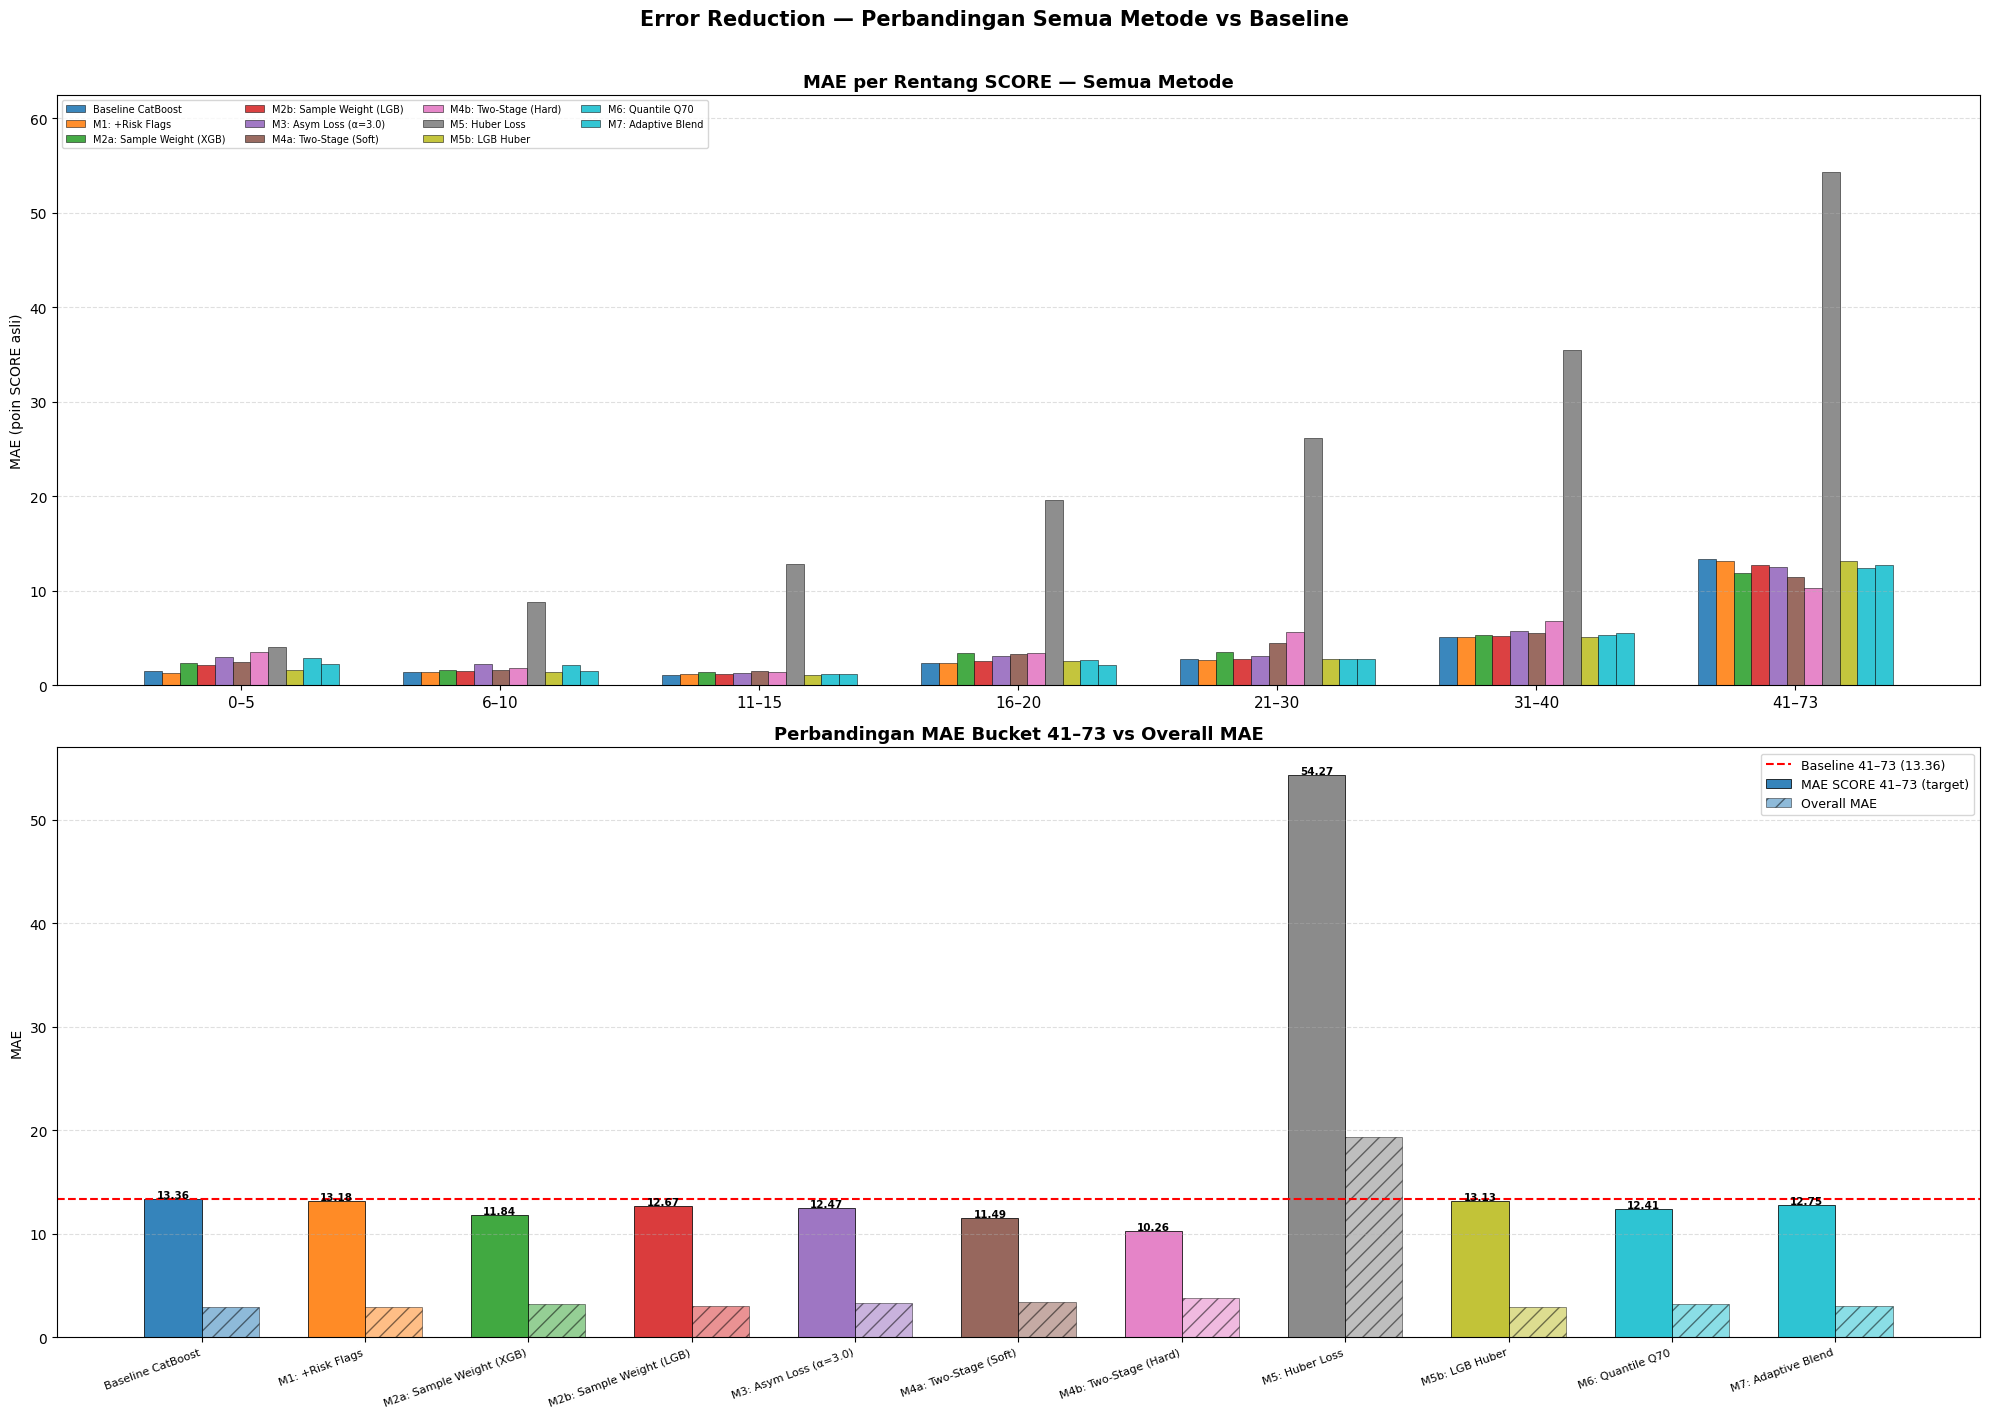

In [93]:
labels_plot = ['0–5', '6–10', '11–15', '16–20', '21–30', '31–40', '41–73']

model_names_clean = [k.replace('\n', ' ') for k in all_results.keys()]

fig, axes = plt.subplots(2, 1, figsize=(20, 14))

x = np.arange(len(labels_plot))

n_models = len(all_results)

width = 0.75 / n_models

cmap = plt.cm.get_cmap('tab10', n_models)

for i, (name, (mae_o, r2, bucket)) in enumerate(all_results.items()):

    maes = [bucket.get(lbl, np.nan) for lbl in labels_plot]

    offset = (i - n_models/2 + 0.5) * width

    bars = axes[0].bar(x + offset, maes, width,

                       label=name.replace('\n', ' '),

                       color=cmap(i), edgecolor='black', linewidth=0.4, alpha=0.88)

axes[0].set_xticks(x)

axes[0].set_xticklabels(labels_plot, fontsize=11)

axes[0].set_title('MAE per Rentang SCORE — Semua Metode', fontsize=13, fontweight='bold')

axes[0].set_ylabel('MAE (poin SCORE asli)')

axes[0].legend(fontsize=7, ncol=4, loc='upper left')

axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylim(0, max(v[2].get('41–73', 0) for v in all_results.values()) * 1.15)

maes_high = [v[2].get('41–73', np.nan) for v in all_results.values()]

maes_ov   = [v[0] for v in all_results.values()]

colors_bar = [cmap(i) for i in range(n_models)]

x2 = np.arange(n_models)

w2 = 0.35

bars1 = axes[1].bar(x2 - w2/2, maes_high, w2, label='MAE SCORE 41–73 (target)',

                    color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.9)

bars2 = axes[1].bar(x2 + w2/2, maes_ov, w2, label='Overall MAE',

                    color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.5,

                    hatch='//')

for bar, val in zip(bars1, maes_high):

    if not np.isnan(val):

        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1,

                     f'{val:.2f}', ha='center', fontsize=7.5, fontweight='bold')

axes[1].axhline(baseline_41_73, color='red', linestyle='--', linewidth=1.5,

                label=f'Baseline 41–73 ({baseline_41_73:.2f})')

axes[1].set_xticks(x2)

axes[1].set_xticklabels(model_names_clean, rotation=20, ha='right', fontsize=8)

axes[1].set_title('Perbandingan MAE Bucket 41–73 vs Overall MAE', fontsize=13, fontweight='bold')

axes[1].set_ylabel('MAE')

axes[1].legend(fontsize=9)

axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Error Reduction — Perbandingan Semua Metode vs Baseline',

             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()

plt.show()

Metode terbaik untuk SCORE 41–73: M4b: Two-Stage (Hard)


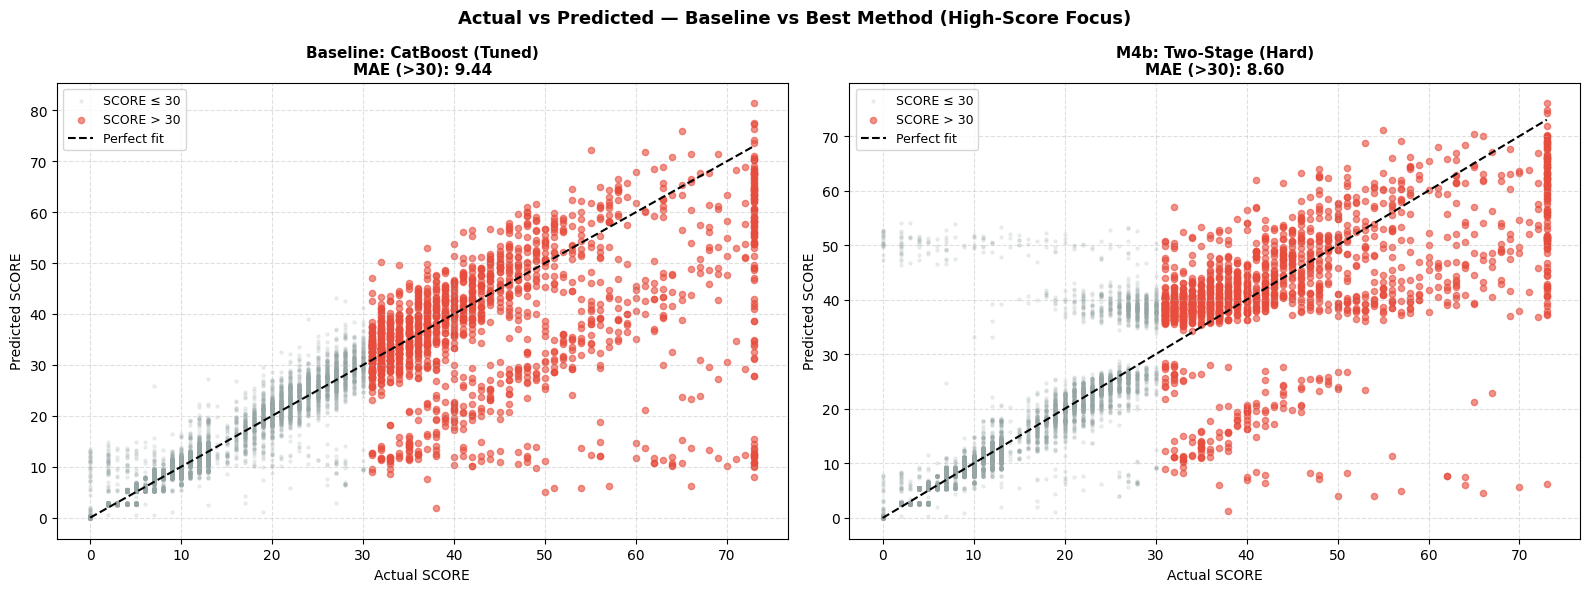

In [94]:
best_method_name = min(

    {k: v[2].get('41–73', 99) for k, v in all_results.items() if k != 'Baseline\nCatBoost'},

    key=lambda k: all_results[k][2].get('41–73', 99)

)

print(f'Metode terbaik untuk SCORE 41–73: {best_method_name.replace(chr(10), " ")}')

best_pred_map = {

    'M1: +Risk\nFlags':          y_pred_f1,

    'M2a: Sample\nWeight (XGB)': y_pred_sw,

    'M2b: Sample\nWeight (LGB)': y_pred_lgb_sw,

    f'M3: Asym\nLoss (α={ALPHA_ASYM})': y_pred_asym,

    'M4a: Two-Stage\n(Soft)':    y_pred_m4_soft,

    'M4b: Two-Stage\n(Hard)':    y_pred_m4_hard,

    'M5: Huber\nLoss':           y_pred_huber,

    'M5b: LGB\nHuber':           y_pred_lgb_hub,

    f'M6: Quantile\nQ{int(QUANTILE*100)}': y_pred_q70,

    'M7: Adaptive\nBlend':       y_pred_blend,

}

y_pred_best = best_pred_map.get(best_method_name, y_pred_baseline)

y_actual_orig = np.expm1(y_test.values)

y_pred_baseline_orig = np.expm1(y_pred_baseline)

y_pred_best_orig     = np.expm1(y_pred_best)

mask_high_test = y_actual_orig > 30

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pred_orig, name) in zip(axes, [

    (y_pred_baseline_orig, 'Baseline: CatBoost (Tuned)'),

    (y_pred_best_orig, best_method_name.replace(chr(10), ' ')),

]):

    ax.scatter(y_actual_orig[~mask_high_test], pred_orig[~mask_high_test],

               alpha=0.15, s=5, color='#95a5a6', label='SCORE ≤ 30')

    ax.scatter(y_actual_orig[mask_high_test], pred_orig[mask_high_test],

               alpha=0.6, s=20, color='#e74c3c', label='SCORE > 30')

    mx = y_actual_orig.max()

    ax.plot([0, mx], [0, mx], 'k--', linewidth=1.5, label='Perfect fit')

    mae_h = np.abs(y_actual_orig[mask_high_test] - pred_orig[mask_high_test]).mean()

    ax.set_title(f'{name}\nMAE (>30): {mae_h:.2f}', fontsize=11, fontweight='bold')

    ax.set_xlabel('Actual SCORE')

    ax.set_ylabel('Predicted SCORE')

    ax.legend(fontsize=9)

    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('Actual vs Predicted — Baseline vs Best Method (High-Score Focus)',

             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()

In [95]:
print('=' * 90)

print('  KESIMPULAN AKHIR — METODE TERBAIK PER TUJUAN')

print('=' * 90)

df_final = df_summary.copy()

df_final['Δ MAE Overall'] = (df_final['Overall MAE'] - df_final.loc['Baseline CatBoost', 'Overall MAE']).round(3)

df_final['Δ MAE 41–73']  = (df_final['MAE 41–73']  - df_final.loc['Baseline CatBoost', 'MAE 41–73']).round(3)

cols_show = ['Overall MAE', 'R²', 'MAE 31–40', 'MAE 41–73', 'Δ MAE Overall', 'Δ MAE 41–73']

print(df_final[cols_show].to_string())

print('\n💡 Keterangan Δ: negatif = perbaikan (MAE turun)')

print('\n🏆 Rekomendasi:')

best_for_high  = df_final['MAE 41–73'].idxmin()

best_for_ovr   = df_final['Overall MAE'].idxmin()

print(f'  Terbaik untuk SCORE 41–73 : {best_for_high}')

print(f'    MAE 41–73 = {df_final.loc[best_for_high, "MAE 41–73"]:.3f} '

      f'(Baseline: {df_final.loc["Baseline CatBoost", "MAE 41–73"]:.3f})')

print(f'  Terbaik untuk Overall MAE  : {best_for_ovr}')

print(f'    MAE = {df_final.loc[best_for_ovr, "Overall MAE"]:.3f} '

      f'(Baseline: {df_final.loc["Baseline CatBoost", "Overall MAE"]:.3f})')

  KESIMPULAN AKHIR — METODE TERBAIK PER TUJUAN
                          Overall MAE         R²  MAE 31–40  MAE 41–73  Δ MAE Overall  Δ MAE 41–73
Model                                                                                             
Baseline CatBoost               2.909      0.853      5.098     13.355          0.000        0.000
M1: +Risk Flags                 2.881      0.878      5.083     13.184         -0.028       -0.171
M2a: Sample Weight (XGB)        3.239      0.832      5.301     11.841          0.330       -1.514
M2b: Sample Weight (LGB)        2.987      0.844      5.162     12.669          0.078       -0.686
M3: Asym Loss (α=3.0)           3.338      0.812      5.693     12.472          0.429       -0.883
M4a: Two-Stage (Soft)           3.442      0.824      5.520     11.485          0.533       -1.870
M4b: Two-Stage (Hard)           3.738      0.771      6.771     10.255          0.829       -3.100
M5: Huber Loss                 19.319 -95262.628     35.443   